Full Stack Deep Learning 03  
Last modified : 2026.04   
제작 : 박광석 (모두의연구소)  

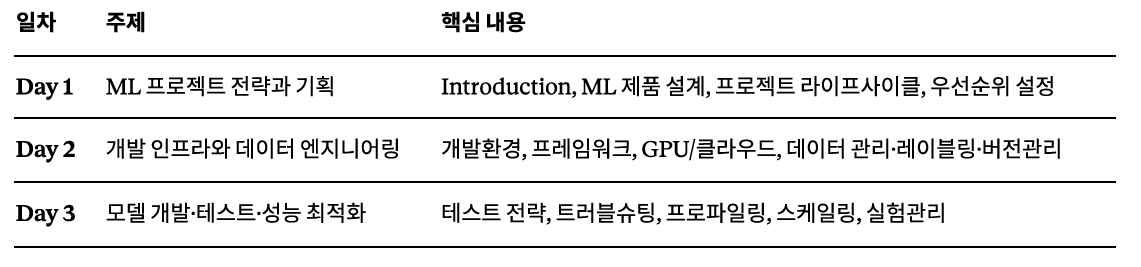

# Day 3. 모델 테스트·트러블슈팅·성능 최적화

> **Day 2 복습**: 개발 환경, PyTorch Lightning, GPU/클라우드 인프라, 데이터 관리의 실전 기술을 다루었습니다. 오늘은 이 인프라 위에서 **모델을 테스트하고, 문제를 진단하고, 성능을 끌어올리는** 체계적인 전략을 학습합니다.
>
> **오늘의 핵심 격언**: "구동되게 만들고(Make it run), 빠르게 만들고(Make it fast), 올바르게 만들어라(Make it right)." ML에서는 이 순서가 특히 중요합니다 — 성능을 개선하려면 먼저 빠른 실험 주기가 확보되어야 하기 때문입니다.

---



## Chapter 13. ML 시스템의 테스트 전략 — "소프트웨어 테스트의 다크 소울"



### 13.1 왜 ML 테스트는 특별히 어려운가

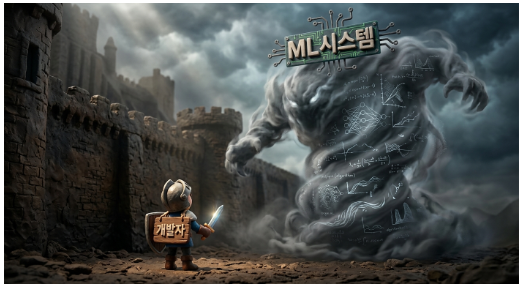



여러분은 소프트웨어 테스트의 기본 개념을 알고 있을 것입니다. 함수에 입력을 넣고, 기대 출력과 비교하면 됩니다. 하지만 ML 시스템의 테스트는 이보다 훨씬 까다롭습니다. 그래서 "소프트웨어 테스트의 다크 소울(Dark Souls)"이라고 불립니다.

| 비교 항목 | 전통 소프트웨어 | 머신러닝 |
| :--- | :--- | :--- |
| 구성 요소 | 소스 코드 → 컴파일러 → 프로그램 | 데이터 + 코드 → 학습 → 모델 |
| 입력의 특성 | 코드는 명시적이고 검사 가능 | 데이터는 무겁고 불투명함 |
| 변환 과정 | 컴파일은 성숙하고 예측 가능 | 학습 과정은 복잡하고 확률적 |
| 디버깅 | 디버거로 모든 상태 추적 가능 | 모델 내부를 들여다보기 매우 힘듦 |
| 정답 기준 | 테스트 통과 = "맞다" | 손실이 0이 아닌 것이 정상 |


### 13.2 테스트 수트를 '분류기'로 생각하기

테스트 수트(Test Suite)를 하나의 **분류기(Classifier)**로 생각하면 직관이 선명해집니다.

- 분류 문제: "이 코드 커밋에 버그가 있는가(Buggy) 아닌가(OK)?"
- 분류기 출력: 테스트 통과(Pass) 또는 실패(Fail)
- 트레이드오프: **탐지(Detection)** vs. **오탐(False Alarms)**

많은 개발자가 "모든 버그를 잡겠다"는 탐지에만 집중하다가, 오탐을 너무 많이 만듭니다. 오탐의 전형적인 증거: 테스트가 실패했는데, 코드를 수정하는 대신 **테스트 코드 자체를 수정해서** 통과시키는 상황입니다. 이것은 테스트의 가치를 무너뜨립니다.

테스트를 추가하기 전에 항상 두 가지를 자문하세요:
1. 이 테스트가 실제로 어떤 종류의 버그를 잡아낼 것인가?
2. 이 테스트가 유효한 코드 변경에 대해 어떤 오탐을 일으킬 수 있는가?

두 번째가 더 많이 떠오른다면, 도입하지 않는 것이 낫습니다. 100% 코드 커버리지가 목표가 되어서는 안 됩니다 — 테스트는 **'증명'이 아니라 '위험 관리'** 의 수단입니다.

예외: 자율주행, 의료 진단, 금융 시스템처럼 생명이나 재산에 직결되는 고위험 자율 시스템은 규제 기관의 요구에 따라 훨씬 더 높은 수준의 엄격한 테스트가 필요합니다.



### 13.3 ML 프로젝트를 위한 표준 테스트 인프라

ML 특화 테스트 이전에, 기본 소프트웨어 테스트 인프라부터 갖춰야 합니다.

**Pytest — 파이썬 테스트의 표준**: 마크(Marks)를 이용한 테스트 그룹화, 리소스 공유(Fixtures), 파라미터화된 테스트를 지원합니다.


핵심 차이는 마지막 줄입니다. 전통 소프트웨어에서는 테스트를 통과하면 "맞다"고 간주합니다. 하지만 **ML 모델은 항상 어느 정도는 틀려 있습니다.** 학습 중 마주하는 0이 아닌 손실(Non-zero loss)은 "부분적인 테스트 실패"입니다. 따라서 ML 테스트는 "맞느냐 틀리느냐"가 아니라 **"얼마나 틀리느냐가 허용 범위 안에 있느냐"** 를 판단하는 것입니다.

또 한 가지 중요한 차이: 전통 소프트웨어는 결정론적(Deterministic)입니다 — 같은 입력에 항상 같은 출력이 나옵니다. 하지만 ML 모델은 확률적(Probabilistic)이며, 동일한 환경에서도 부동 소수점 오차나 데이터 셔플링에 따라 결과가 미세하게 달라질 수 있습니다. 따라서 ML 테스트는 '값이 정확히 일치하는가'보다 **'통계적 분포가 허용 범위 내에 있는가'** 를 측정하는 방향으로 설계되어야 합니다.

어렵지만 불가능한 것은 아닙니다. 다크 소울의 보스를 결국 클리어하는 게이머들처럼, 체계적인 접근법으로 ML 시스템의 신뢰성을 확보할 수 있습니다.


```python
# tests/test_model.py
import torch
import pytest
from my_project.model import LitClassifier

@pytest.fixture
def model():
    """테스트 전체에서 공유하는 모델 인스턴스"""
    return LitClassifier(hidden_dim=64)

@pytest.fixture
def sample_batch():
    """테스트용 가짜 배치"""
    x = torch.randn(8, 1, 28, 28)
    y = torch.randint(0, 10, (8,))
    return x, y

def test_output_shape(model, sample_batch):
    """모델 출력의 shape이 올바른지 확인"""
    x, y = sample_batch
    logits = model(x)
    assert logits.shape == (8, 10), f"Expected (8, 10), got {logits.shape}"

def test_output_range(model, sample_batch):
    """출력 logits에 NaN이나 Inf가 없는지 확인"""
    x, y = sample_batch
    logits = model(x)
    assert torch.isfinite(logits).all(), "NaN or Inf detected in model output"

def test_loss_decreases(model, sample_batch):
    """단일 배치에서 1 step 학습 후 loss가 감소하는지 확인"""
    x, y = sample_batch
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)

    logits = model(x)
    loss_before = torch.nn.functional.cross_entropy(logits, y).item()

    loss = torch.nn.functional.cross_entropy(model(x), y)
    loss.backward()
    optimizer.step()

    logits_after = model(x)
    loss_after = torch.nn.functional.cross_entropy(logits_after, y).item()

    assert loss_after < loss_before, "Loss did not decrease after one training step"
```

이 세 가지 테스트만으로도 상당한 범위의 치명적 버그를 잡을 수 있습니다. Shape 테스트는 레이어 연결 오류를, NaN 테스트는 수치적 불안정을, Loss 감소 테스트는 그래디언트 흐름 단절을 감지합니다.

**주피터 노트북 테스트**: 노트북은 시각화에는 좋지만 테스트하기 어렵습니다. "싸고 더러운(Cheap and Dirty)" 해결책으로, 노트북을 처음부터 끝까지 실행(End-to-End)하고 중간중간 `assert`를 추가한 뒤 `nbformat`으로 자동 실행하는 루틴을 만듭니다. Day 2에서 배운 "핵심 로직은 `.py` 모듈로 분리"하는 습관이 여기서 빛을 발합니다 — `.py` 파일은 Pytest로 쉽게 테스트할 수 있기 때문입니다.

**계층적 테스트 수트(Tiered Testing):**
- **PR/Push 단계 (10분 이내)**: Shape 검증, NaN 검사, 암기 테스트, 린팅
- **Nightly(야간) 단계**: 전체 데이터셋 일부로 진행하는 학습 회귀 테스트, 성능 벤치마크
- **Weekly/Release 단계**: 전체 데이터셋 학습, 편향성(Bias) 평가, A/B 테스트 전 최종 검증



### 13.4 데이터 품질을 위한 기댓값 테스트 (Expectation Testing)

ML에서 "데이터는 새로운 코드"입니다. 코드에 버그가 있으면 프로그램이 죽지만, 데이터에 오류가 있으면 모델이 **조용히 잘못된 것을 학습**합니다. 이것이 더 위험합니다.

**기댓값 테스트의 철학 — 스모크 테스트부터 시작하세요**

모든 버그를 잡으려 하기보다, 우선 "시스템에 불이 났는지" 확인하는 스모크 테스트에 집중하세요. 데이터에 대해 가지고 있는 기본적인 가정을 명시적 코드로 만드는 것입니다.

```python
def smoke_test_training_data(df):
    """데이터 파이프라인에 '불이 났는지' 확인"""
    # 1. 결측치 — 필수 컬럼에 Null이 있으면 학습 자체가 실패할 수 있음
    assert df['user_id'].isnull().sum() == 0, "user_id에 결측치 발견"  # user_id 컬럼이 널인게 있으면 "user_id에 결측치 발견" 메세징.
    assert df['label'].isnull().sum() == 0, "label에 결측치 발견"

    # 2. 논리적 선후 관계
    if 'end_date' in df.columns and 'start_date' in df.columns:
        assert (df['end_date'] >= df['start_date']).all(), \
            "종료일이 시작일보다 빠른 데이터 존재"

    # 3. 값의 범위 — 느슨하게! (오탐 방지가 핵심)
    if 'height' in df.columns:
        assert df['height'].min() >= 0, "키는 음수일 수 없음"
        assert df['height'].max() <= 30, "키 30피트 초과 — 단위 변환 오류 의심"

    # 4. 레이블 분포 — 클래스가 극단적으로 불균형하지 않은지
    label_counts = df['label'].value_counts(normalize=True)
    assert label_counts.min() > 0.01, \
        f"클래스 '{label_counts.idxmin()}'가 전체의 1% 미만 — 극단적 불균형"

    # 5. 데이터 크기 — 예상 범위 내인지
    assert len(df) > 100, f"데이터가 너무 적음: {len(df)}행"

    print(f"✅ 스모크 테스트 통과 ({len(df)}행, {df['label'].nunique()}개 클래스)")
```

**"느슨한 경계" 원칙이 핵심입니다.** 사람의 키가 보통 4~8피트라고 해서 그 범위로 잡으면, 정상 데이터인데도 테스트가 실패(오탐)합니다. "키는 음수일 수 없고 30피트를 넘을 수 없다" 정도로 느슨하게 잡으면, 인치를 피트로 잘못 입력하는 것 같은 **진짜 불이 난 상황**은 잡으면서 불필요한 알람은 줄입니다.

**기댓값을 점진적으로 강화하세요**: 처음에는 느슨한 기댓값으로 시작하여, 데이터에 대한 이해가 깊어지면 통계적 범위를 활용한 더 정교한 기댓값(예: "99%의 데이터가 평균으로부터 3표준편차 이내에 있어야 함")을 추가합니다. 이는 데이터 드리프트를 감지하는 첫 번째 방어선이 됩니다.

**데이터 품질의 6대 차원**: 기댓값 테스트를 체계적으로 설계할 때 다음 6가지 기준을 고려하세요 — 정확성(Accuracy), 완전성(Completeness: Null 체크), 일관성(Consistency: 시스템 간 모순 여부), 적시성(Timeliness: 최신 데이터 공급), 유효성(Validity: 형식/범위), 고유성(Uniqueness: 중복 여부).

**Great Expectations — 전문 도구**: `assert`문으로 시작하되, 파이프라인이 복잡해지면 Great Expectations 같은 전문 도구로 전환하세요. 자동 문서화, 시각적 품질 보고서, 알림 시스템을 내장하고 있어, 데이터 파이프라인의 각 단계(수집 → 전처리 → 학습 직전)에 검증 게이트를 배치할 수 있습니다.

**파이프라인 단계별 기댓값 배치 전략**: 데이터 파이프라인은 보통 수집 → 전처리 → 피처 엔지니어링 → 학습 직전 저장의 단계를 거칩니다. 각 단계의 출력에 기댓값 테스트를 배치하면, 어느 단계에서 데이터가 오염되었는지 정확히 파악할 수 있습니다. 전통적인 데이터베이스는 저장 시점에 형식을 강제(Schema on Write)하지만, ML 데이터 레이크는 먼저 저장하고 나중에 해석(Schema on Read)하는 경우가 많습니다. 따라서 저장 단계에서 걸러지지 못한 오류를 잡아내기 위해, 각 파이프라인 단계에 검증 게이트를 배치하는 "방어적 코딩"이 필수적입니다.

```python
# 파이프라인 단계별 기댓값 테스트 설계 예시
def validate_raw_data(df):
    """수집 직후 — 가장 느슨한 검증"""
    assert len(df) > 0, "데이터가 비어 있음"   # len(df) == 0 이면 "데이터가 비어 있음" 메세징
    assert 'user_id' in df.columns, "user_id 컬럼 누락"
    assert 'timestamp' in df.columns, "timestamp 컬럼 누락"

def validate_preprocessed_data(df):
    """전처리 후 — 형식과 범위 검증"""
    assert df['user_id'].isnull().sum() == 0, "user_id 결측치"
    assert df['age'].between(0, 150).all(), "비현실적인 나이 값"
    assert df['price'].min() >= 0, "음수 가격"
    # 전처리로 생성된 새로운 컬럼이 존재하는지
    assert 'normalized_price' in df.columns, "정규화 컬럼 누락 — 전처리 실패"

def validate_training_ready(df):
    """학습 직전 — 가장 엄격한 검증"""
    assert df.duplicated().sum() == 0, "중복 레코드 발견"
    label_dist = df['label'].value_counts(normalize=True)
    assert label_dist.min() > 0.01, f"극단적 클래스 불균형: {label_dist.to_dict()}"
    # 이전 학습 데이터와 통계적 분포 비교 (드리프트 감지의 첫걸음)
    assert abs(df['feature_1'].mean() - EXPECTED_MEAN) < TOLERANCE, "피처 분포 변화 감지"
```

**Great Expectations 실전 활용**: 위의 `assert`문 방식은 시작점으로 좋지만, 팀이 커지고 파이프라인이 복잡해지면 전문 도구가 필요합니다. Great Expectations는 기댓값 테스트에 더해 자동 문서화(데이터 사양서 자동 생성), 시각적 품질 보고서, 내장 알림 시스템을 제공합니다. 처음에는 `assert`로 시작하고, 파이프라인에 3개 이상의 데이터 소스가 연결되는 시점에서 전환을 고려하세요.

**실서비스 사례 — Uber의 데이터 품질 관리**: Uber는 수천 개의 ML 모델을 운영하면서, 데이터 파이프라인 중 하나의 컬럼 이름이 바뀌어 전체 모델 학습이 실패한 경험이 있었습니다. 이후 모든 데이터 파이프라인 단계에 스키마 검증과 통계적 기댓값 테스트를 배치하는 "데이터 품질 게이트(Data Quality Gate)" 정책을 도입했습니다. 핵심 교훈: 데이터 오류는 모델 오류보다 찾기 어렵고 파급력이 크므로, 방어적 코딩이 필수적입니다.

**엔지니어가 데이터에 가까워지는 4단계 성숙도**: 테스트 도구보다 더 중요한 것은 엔지니어가 직접 데이터를 들여다보는 것입니다.
- Level 0 (최악): 외부 벤치마크 데이터만 사용하고, 실제 운영 데이터를 본 적 없음
- Level 1: 데이터 수집은 외부 팀에 맡기지만, 가끔 샘플을 확인함
- Level 2: 정기적으로 데이터 품질 보고서를 확인하고 기댓값 테스트를 관리
- Level 3 (최선): 모델 개발자가 정기적으로 '온콜(On-call) 로테이션'을 통해 실제 운영 데이터를 직접 레이블링하고, 에지 케이스를 체험함

여러분이 Level 3에 가까울수록, 더 좋은 기댓값 테스트를 설계하고, 더 빠르게 데이터 문제를 발견할 수 있습니다.



### 13.5 학습 코드 검증을 위한 암기 테스트 (Memorization Testing)

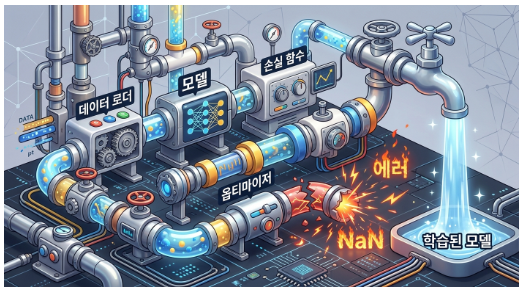



Day 2에서 `overfit_batches=1`을 소개했는데, 이것이 왜 그토록 강력한 도구인지 이제 깊이 파헤칩니다.

**핵심 철학: "암기는 학습의 가장 단순한 형태이다."**

심층 신경망은 파라미터 수가 매우 많기 때문에 소량의 데이터를 완벽하게 암기하는 능력이 탁월합니다. 레이블이 무작위(Random)일지라도 완벽하게 암기할 수 있습니다. 따라서 모델이 단 1개의 배치조차 암기하지 못한다면, 이는 모델의 학습 능력 문제가 아니라 **코드의 물리적 연결이 끊어져 있다**는 의미입니다.

비유로 설명하자면: 수도 배관을 새로 설치한 뒤, 물이 나오는지 확인하는 것입니다. 물이 안 나온다면 수도꼭지의 디자인이 문제가 아니라, 배관 어딘가가 연결되지 않은 것입니다. 암기 테스트는 `DataLoader → Model → Loss → Optimizer → GPU` 파이프라인의 모든 배관이 새지 않고 연결되어 있는지 증명합니다.

**암기 테스트가 잡아내는 치명적 결함들:**
- **그래디언트 계산 오류**: `loss.backward()`는 실행되지만, 특정 레이어의 파라미터에 그래디언트가 전파되지 않는 경우. `.requires_grad`가 `False`로 설정되어 있거나, 연산 그래프가 중간에 끊어진 경우입니다.
- **데이터 셔플링 오류**: `DataLoader`에서 x와 y의 순서가 뒤섞여, 모델이 아무리 학습해도 정답을 맞출 수 없는 경우. 놀랍도록 흔한 버그입니다.
- **전처리 버그**: 정규화 값이 잘못되어(예: 평균을 빼야 하는데 더한 경우) 모델이 의미 있는 패턴을 학습하지 못하는 경우.
- **수치적 문제**: 그래디언트 폭주나 소실로 NaN/Inf가 발생하는 경우.
- **옵티마이저 설정 오류**: 학습률이 0이거나, 잘못된 파라미터 그룹이 전달된 경우.

**실전 구현 — Lightning으로 2줄이면 충분합니다:**

```python
# 모든 규제를 끄세요 — 암기는 의도적인 오버피팅입니다
trainer = pl.Trainer(
    overfit_batches=1,              # 단 1개 배치만 사용
    max_epochs=50,                  # 충분한 에포크
    accelerator="auto",
    enable_checkpointing=False,     # 테스트이므로 불필요
    logger=False,                   # 로깅도 불필요
)
trainer.fit(model, train_loader)
# 결과: Loss가 0에 가까워지면 통과 ✅, 그렇지 않으면 코드에 버그 ❌
```

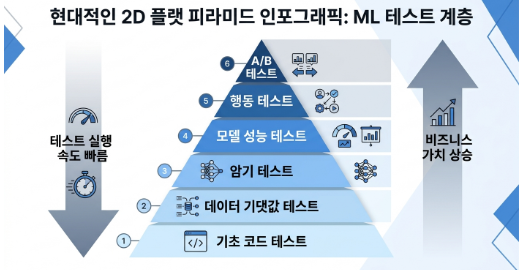


아래로 갈수록 실행이 빠르고, 위로 갈수록 비즈니스 가치에 가깝습니다. 아래 층이 견고하지 않으면 위 층은 의미가 없습니다. 많은 팀이 "모델 정확도"부터 측정하려 하지만, 기초 코드 테스트와 데이터 기댓값 테스트가 없으면 정확도 수치 자체를 신뢰할 수 없습니다.

**실서비스 사례 — Google의 ML 테스트 문화**: Google은 내부적으로 "ML Test Score"라는 프레임워크를 사용하여 팀의 ML 테스트 성숙도를 0 ~ 8점으로 평가합니다. 점수가 낮은 팀(0 ~ 2점)은 데이터 기댓값 테스트와 암기 테스트조차 없는 상태이고, 높은 팀(6 ~ 8점)은 자동화된 성능 벤치마크, 편향성 평가, A/B 테스트까지 갖추고 있습니다. 대부분의 팀이 시작해야 할 곳은 피라미드의 맨 아래 — 기초 코드 테스트와 데이터 기댓값 테스트입니다.



### 13.6 행동 테스트(Behavioral Testing)와 메타모픽 테스팅

정답(Ground Truth)을 모르는 상황에서도 모델의 "행동 패턴"이 올바른지 검증할 수 있습니다. NLP의 CheckList 논문에서 제안된 접근법으로, 모델에 기대하는 불변성(Invariance)과 방향성(Directional) 규칙을 테스트합니다.

**불변성 테스트(Invariance Test)**: 입력을 바꿔도 출력이 같아야 하는 경우.
- 감성 분석: "이 영화는 훌륭하다" → "이 영화는 훌륭합니다" (어미 변경) → 감성 판단은 동일해야 함
- 이미지 분류: 이미지를 좌우 반전해도 분류 결과는 같아야 함

**방향성 테스트(Directional Test)**: 입력을 바꾸면 출력이 특정 방향으로 변해야 하는 경우.
- 감성 분석: "이 영화는 훌륭하다" → "이 영화는 별로다" → 감성 점수가 하락해야 함
- 추천 시스템: 사용자가 특정 카테고리를 많이 클릭하면, 해당 카테고리 추천 비율이 올라가야 함

주의: 암기 테스트 시에는 모델의 **Dropout, Data Augmentation 등 모든 규제(Regularization)를 끄세요**. 이들은 의도적으로 오버피팅을 방해하는 기법이므로, 암기 테스트에서는 방해물이 됩니다.

**10분의 법칙**: 테스트가 너무 오래 걸리면 엔지니어들이 건너뛰게 됩니다. 암기 테스트는 10분 이내에 완료되도록 튜닝하세요:
1. 데이터셋을 배치 사이즈 수준으로 축소
2. 모든 규제 제거
3. 모델 크기 축소 (아키텍처는 유지하되 레이어 너비/깊이 감소)
4. 가장 비싼 컴포넌트를 일시적으로 제외

**회귀 감지로의 확장**: 단순히 "암기가 가능한가"를 넘어, 목표 손실에 도달하기까지의 **에포크 수나 실행 시간**을 기록하세요. 이전 커밋보다 암기 속도가 현저히 느려졌다면, 성능 저하를 유발하는 잠재적 버그가 도입되었다는 신호입니다.

**ML 테스트 피라미드**: 전통 소프트웨어의 테스트 피라미드(단위 테스트 → 통합 테스트 → E2E 테스트)를 ML 맥락으로 재구성하면 다음과 같습니다:


```python
def test_sentiment_invariance(model, tokenizer):
    """어미 변경에 모델이 불변해야 함"""
    texts = [
        ("이 영화는 정말 좋다", "이 영화는 정말 좋습니다"),
        ("서비스가 최악이다", "서비스가 최악입니다"),
    ]
    for text_a, text_b in texts:
        score_a = model.predict(tokenizer(text_a))
        score_b = model.predict(tokenizer(text_b))
        assert abs(score_a - score_b) < 0.1, \
            f"Invariance violated: '{text_a}'={score_a:.2f}, '{text_b}'={score_b:.2f}"
```

**실서비스 사례 — Microsoft의 CheckList**: Microsoft Research가 상용 감성 분석 API(AWS, Google, Azure 포함)에 CheckList를 적용했을 때, 모든 상용 API에서 심각한 행동 결함이 발견되었습니다. 예를 들어, "I am happy"는 긍정으로 분류하면서 "I am not unhappy"(이중 부정 = 긍정)는 부정으로 분류하는 오류가 발견되었습니다. 행동 테스트는 전통적인 정확도 메트릭으로는 포착하기 어려운 이런 "패턴적 결함"을 찾아냅니다.

**행동 테스트 실전 설계 가이드 — 어떻게 테스트 케이스를 만들 것인가**

행동 테스트를 설계할 때 가장 어려운 부분은 "어떤 변환을 테스트해야 하는가?"를 결정하는 것입니다. CheckList 논문에서 제안하는 체계적인 접근법을 소개합니다.

**능력 1: 어휘 + 구문 이해 (Vocabulary + POS)**
- 부정 표현: "좋다" → "좋지 않다" → 감성 반전 확인
- 동의어: "훌륭하다" → "탁월하다" → 감성 유지 확인
- 비교급: "A가 B보다 낫다" → A에 대한 감성이 더 높아야 함

**능력 2: 강건성 (Robustness)**
- 오타 삽입: "이 영화는 정말 좋앗다" → 결과가 크게 바뀌면 안 됨
- 축약어/비속어: 실제 사용자 데이터에는 정제되지 않은 표현이 포함됨
- 무관한 정보 추가: "참고로 오늘 날씨가 좋은데, 이 영화는 최고다" → "날씨" 언급이 감성에 영향을 주면 안 됨

**능력 3: NER / 고유명사**
- 사람 이름 교체: "김철수의 연기가 좋다" → "이영희의 연기가 좋다" → 감성 유지
- 이것이 실패하면 모델이 특정 이름에 대한 편향을 학습한 것일 수 있음

```python
def test_negation_handling(model):
    """부정 표현을 올바르게 처리하는지 확인"""
    positive = "이 서비스는 정말 편리합니다"
    negated = "이 서비스는 정말 편리하지 않습니다"

    score_pos = model.predict_sentiment(positive)
    score_neg = model.predict_sentiment(negated)

    assert score_pos > 0.5, f"긍정 문장이 긍정으로 분류되지 않음: {score_pos}"
    assert score_neg < 0.5, f"부정 문장이 부정으로 분류되지 않음: {score_neg}"
    assert score_pos > score_neg + 0.3, "긍정/부정 간 점수 차이가 충분하지 않음"

def test_robustness_to_typos(model):
    """오타에 강건한지 확인 — 실사용자 데이터에는 오타가 많음"""
    original = "이 영화는 정말 재미있었다"
    with_typo = "이 영화는 정말 재미있엇다"  # 오타 포함

    score_orig = model.predict_sentiment(original)
    score_typo = model.predict_sentiment(with_typo)

    assert abs(score_orig - score_typo) < 0.15, \
        f"오타에 민감: 원본={score_orig:.2f}, 오타={score_typo:.2f}"
```
  

```python
def test_negation_handling(model):
    """부정 표현을 올바르게 처리하는지 확인"""
    positive = "이 서비스는 정말 편리합니다"
    negated = "이 서비스는 정말 편리하지 않습니다"

    score_pos = model.predict_sentiment(positive)
    score_neg = model.predict_sentiment(negated)

    assert score_pos > 0.5, f"긍정 문장이 긍정으로 분류되지 않음: {score_pos}"
    assert score_neg < 0.5, f"부정 문장이 부정으로 분류되지 않음: {score_neg}"
    assert score_pos > score_neg + 0.3, "긍정/부정 간 점수 차이가 충분하지 않음"

def test_robustness_to_typos(model):
    """오타에 강건한지 확인 — 실사용자 데이터에는 오타가 많음"""
    original = "이 영화는 정말 재미있었다"
    with_typo = "이 영화는 정말 재미있엇다"  # 오타 포함

    score_orig = model.predict_sentiment(original)
    score_typo = model.predict_sentiment(with_typo)

    assert abs(score_orig - score_typo) < 0.15, \
        f"오타에 민감: 원본={score_orig:.2f}, 오타={score_typo:.2f}"
```

### 13.7 ML 시스템에서의 테스트 주도 개발(TDD)

Andrej Karpathy의 통찰을 빌리면, **"경사 하강법(Gradient Descent)은 그 자체가 TDD이다."**

행동 테스트는 처음 만들 때 시간이 걸리지만, 한번 구축하면 모델을 업데이트할 때마다 **회귀 테스트(Regression Test)**로 재사용됩니다. "새 모델이 기존 모델의 행동을 깨뜨리지 않는가?"를 자동으로 확인할 수 있기 때문입니다.


| | 전통적 TDD | ML의 TDD |
| :--- | :--- | :--- |
| **테스트 작성** | 기대 출력 정의 (실패) | 손실 함수(Loss) 정의 |
| **코드 작성** | 테스트를 통과하는 코드 구현 | 모델 학습 (Loss 감소) |
| **테스트 통과** | 기대 출력과 일치 | 목표 Loss 도달 |
| **차이점** | **성공/실패의 이진 판단** | **"얼마나 실패했는가"의 연속 값** |


이 관점에서 보면, 손실 함수를 정의하는 것이 곧 테스트를 작성하는 것이고, 모델 학습은 그 테스트를 점진적으로 통과시키는 과정입니다. Day 1에서 배운 "성공 지표 정의"가 곧 ML에서의 TDD 시작점인 셈입니다.



> **✅ Chapter 13 체크포인트**
> 1. ML 테스트가 "다크 소울"이라 불리는 이유를 전통 소프트웨어와 비교하여 3가지 관점에서 설명할 수 있으신가요?
> 2. 테스트 수트를 "분류기"로 보았을 때, 오탐(False Alarm)이 왜 위험한지 실제 사례를 들어 설명할 수 있으신가요?
> 3. 암기 테스트(`overfit_batches=1`)가 실패했을 때 의심해야 할 원인 5가지를 나열하고, 각각의 디버깅 방법을 떠올릴 수 있으신가요?
> 4. 데이터 기댓값 테스트에서 "느슨한 경계" 원칙이 왜 중요한지, 경계를 너무 엄격하게 잡으면 어떤 문제가 발생하는지 설명해 보세요.
> 5. 행동 테스트의 "불변성 테스트"와 "방향성 테스트"의 차이를 자신의 프로젝트에 적용하여 각각 1개씩 예시를 만들어 보실 수 있나요?

---


**✅ Chapter 13 체크포인트**
1. ML 테스트가 "다크 소울"이라 불리는 이유를 전통 소프트웨어와 비교하여 3가지 관점에서 설명할 수 있으신가요?
  - ML 테스트는 확률과 데이터가 개입하면서 난이도가 급격히 상승.

    - 로직(Code) vs 데이터(Data)의 결합: 기존에는 작성한 코드의 결함만 찾으면 되었습니다. 하지만 ML에서는 코드가 완벽해도 학습 데이터의 분포가 바뀌거나 라벨링에 노이즈가 있으면 시스템이 실패합니다. 버그의 원인이 코드 바깥(데이터 공간)에 존재할 수 있습니다.

    - 결정론(Determinism) vs 확률(Probability): 전통적인 API는 A를 넣으면 반드시 B가 나오거나 명확한 에러 코드(500)를 반환해야 합니다. (assert output == expected). 반면 ML 모델은 확률값을 반환하므로 정확한 단일 값을 단언(Assert)하기 어렵습니다. 95%의 정확도가 오늘은 통과지만 내일은 무작위성(Random Seed) 때문에 94.8%가 되어 실패할 수 있습니다.

    - 명시적 실패 vs 침묵하는 실패(Silent Failure): 기존 시스템은 NullPointerException이나 Syntax Error처럼 시스템이 멈추며 비명을 지릅니다. 하지만 ML 시스템은 에러를 뿜지 않고 학습이 끝까지 완료되는 경우가 많습니다. 코드는 정상적으로 실행되었지만, 예측값은 완전히 망가진 '침묵의 실패'를 잡아내기 훨씬 까다롭습니다.

2. 테스트 수트를 "분류기"로 보았을 때, 오탐(False Alarm)이 왜 위험한지 실제 사례를 들어 설명할 수 있으신가요?
    - 테스트 수트는 "이 코드를 배포해도 안전한가?"를 이진 분류(Pass/Fail)하는 모델과 같습니다. 여기서 오탐(False Alarm)이란, 실제로는 아무 문제가 없는데 테스트가 실패했다고 경고를 울리는 상황입니다.

      - 가장 큰 위험은 '경고 피로(Alert Fatigue)'와 신뢰도 하락입니다.

      - 실제 사례: CI/CD 파이프라인에 모델의 정확도가 90% 이상이어야 통과하는 테스트가 있다고 가정해 보겠습니다. 새로운 데이터를 추가해 재학습했는데 정확도가 89.9%가 나와 파이프라인이 멈췄습니다. 모델 자체는 정상이고 단지 테스트 데이터의 난이도가 미세하게 올라갔을 뿐입니다. 이런 일이 반복되면, 개발자들은 파이프라인이 멈춰도 "아, 또 그 테스트가 오작동했네"라며 테스트를 비활성화하거나 무시하기 시작합니다. 정작 진짜 심각한 성능 저하가 발생했을 때 이를 놓치게 됩니다.

3. 암기 테스트(`overfit_batches=1`)가 실패했을 때 의심해야 할 원인 5가지를 나열하고, 각각의 디버깅 방법을 떠올릴 수 있으신가요?

    - 학습률(Learning Rate) 설정 오류: 학습률이 너무 커서 발산하거나 너무 작아서 갱신되지 않는 경우입니다.
      - 디버깅: 학습률을 $10^{-2}$부터 $10^{-5}$까지 극단적으로 바꿔가며 Loss가 떨어지는지 확인합니다.

    - 데이터-라벨 매핑 오류 (데이터 오염): 전처리 과정에서 이미지/텍스트와 라벨이 섞여버린 경우입니다.
      - 디버깅: 모델에 들어가기 직전의 텐서(Tensor)를 역변환하여 실제 데이터와 라벨이 맞게 짝지어져 있는지 눈으로 직접 확인(Visualization)합니다.

    - 손실 함수(Loss Function) 선택 오류: 분류 문제에 회귀용 손실 함수(MSE)를 쓰거나, Softmax가 이미 적용되었는데 다시 적용하는 등의 문제입니다.
      - 디버깅: 모델의 출력값 형태(Logits인지 Probabilities인지)와 손실 함수의 요구 스펙이 일치하는지 공식 문서를 대조합니다.

    - 기울기(Gradient) 단절 및 소실: 특정 레이어의 requires_grad가 False로 되어 있거나, 연산 그래프가 끊겨 역전파가 안 되는 상황입니다.
      - 디버깅: loss.backward() 직후 각 레이어의 가중치 기울기(Gradient Norm)를 출력하여 0이 나오지 않는지 확인합니다.

    - 모델 용량(Capacity) 부족: 모델의 구조가 너무 단순하여 아주 작은 데이터조차 표현할 능력이 없는 경우입니다.
      - 디버깅: 레이어를 더 깊게 쌓거나 파라미터 수를 일시적으로 늘려 과적합이 일어나는지 테스트해 봅니다.

4. 데이터 기댓값 테스트에서 "느슨한 경계" 원칙이 왜 중요한지, 경계를 너무 엄격하게 잡으면 어떤 문제가 발생하는지 설명해 보세요.

    - 데이터 파이프라인을 검증할 때 기대하는 값의 범위를 너무 엄격하게 잡으면 시스템이 지나치게 경직됩니다.

      - 중요성: 현실 세계의 데이터는 계절, 트렌드, 외부 요인에 의해 자연스럽게 이동(Data Drift)합니다. 느슨한 경계는 이러한 '정상적인 변화'는 허용하면서, '명백한 시스템 에러'만 잡아내는 역할을 합니다.

      - 엄격한 경계의 문제점: 예를 들어, 유통 도메인에서 '일일 평균 결제 금액'의 기댓값을 50,000원 ± 10%로 너무 타이트하게 잡았다고 가정해 보겠습니다. 명절 특수나 대규모 할인 행사로 인해 결제 금액이 이 범위를 벗어나면, 데이터 파이프라인은 이를 오류로 판단하고 학습을 중단시킵니다. 시스템 에러가 아닌 비즈니스의 자연스러운 호황인데도 모델 업데이트가 막혀버리는 치명적인 병목 현상이 발생합니다.

5. 행동 테스트의 "불변성 테스트"와 "방향성 테스트"의 차이를 자신의 프로젝트에 적용하여 각각 1개씩 예시를 만들어 보실 수 있나요?

    - 유통 및 백엔드 시스템에 AI를 접목한 '상품 수요 예측 모델'.

      - 불변성 테스트 (Invariance Test): 입력 데이터의 특성을 살짝 바꾸더라도 모델의 예측값은 변하지 않아야 한다는 테스트입니다.
        - 예시: 상품명 "유기농 사과 1kg"을 "1kg 유기농 사과"로 순서만 변경해서 모델에 넣었을 때, 다음 주 예측 판매량(Demand)은 동일하게 산출되어야 합니다.

      - 방향성 테스트 (Directional Test): 입력 데이터의 특정 요소를 변경했을 때, 예측값이 우리가 기대하는 명확한 방향(증가 또는 감소)으로 움직여야 한다는 테스트입니다.
        - 예시: 특정 상품의 '할인율' 피처(Feature)를 0%에서 50%로 변경해서 입력했을 때, 다음 주 예측 판매량은 원래 예측량보다 반드시 같거나 증가해야 하며, 감소해서는 안 됩니다.


## Chapter 14. 모델 트러블슈팅 3단계 — Make it Run, Make it Fast, Make it Right

소프트웨어 공학의 "작동하게, 올바르게, 빠르게"를 ML에서는 **순서를 바꿔야** 합니다. ML 모델은 항상 어느 정도 틀려 있으므로, "올바르게"는 끝이 없는 여정입니다. 성능을 개선하기 위해 더 많은 실험을 수행하려면, 실험 주기를 단축하는 "빠르게"가 먼저 와야 합니다.



```
Make it Run → Make it Fast → Make it Right
(구동되게)    (빠르게)        (올바르게)
```




### 14.1 1단계: Make it Run — 시끄러운 실패를 해결하라

모델이 아예 멈추거나, 계산 결과가 깨지는 **"시끄러운 실패(Loud failures)"**를 해결하는 단계입니다. 이 단계를 건너뛰고 성능 개선에 몰두하는 것은 기초공사 없이 인테리어를 하는 것과 같습니다.


**14.1.1 Shape 오류 — 가장 흔한 첫 번째 장애물**

텐서의 형태(Shape) 불일치는 모델 개발 초기에 가장 빈번합니다. 실전에서 도움이 되는 습관 3가지:



**습관 1 — 코드 주석에 기대 shape 기록:**

```python
x = self.encoder(input_ids)          # (batch, seq_len, hidden_dim)
x = x.mean(dim=1)                    # (batch, hidden_dim) — 시퀀스 차원 평균
logits = self.classifier(x)          # (batch, num_classes)
```

**습관 2 — 브로드캐스팅(Broadcasting) 경계:** PyTorch는 서로 다른 형태의 텐서를 자동으로 크기를 맞춰 연산합니다. 이것이 편리하기도 하지만, 의도치 않은 브로드캐스팅은 **에러 없이 잘못된 값**을 계산합니다. 예를 들어 `(batch, 1)` 텐서와 `(1, classes)` 텐서를 더하면 `(batch, classes)` 결과가 나오는데, 이것이 의도한 것인지 아닌지 코드만 봐서는 알기 어렵습니다. `unsqueeze`나 `view`로 차원을 명시적으로 제어하세요.

**습관 3 — 디버거 적극 활용:** 에러가 발생하면 `print(tensor.shape)` 대신 VS Code의 중단점(Breakpoint)을 사용하세요. 중단점에서 모든 텐서의 shape, dtype, device를 한눈에 확인할 수 있습니다.

**Shape 오류 디버깅 실전 코드**: 여러분이 겪을 수 있는 전형적인 Shape 오류와 해결법:

```python
# ❌ 흔한 실수 1: 배치 차원을 잃어버림
x = torch.randn(32, 3, 224, 224)  # (batch, channels, H, W)
x = x.mean(dim=(2, 3))            # (32, 3) — 의도: 공간 평균
x = x.mean(dim=0)                  # (3,) — 실수! 배치 차원도 평균냄
# classifier(x)를 호출하면 shape 불일치 발생

# ✅ 수정: dim을 명시적으로 확인
x = x.mean(dim=(2, 3))            # (32, 3)
assert x.dim() == 2, f"Expected 2D, got {x.dim()}D"  # 차원 검증 추가

# ❌ 흔한 실수 2: 브로드캐스팅 함정
labels = torch.tensor([0, 1, 2])        # shape: (3,)
predictions = torch.tensor([[0.1, 0.9], [0.8, 0.2], [0.3, 0.7]])  # shape: (3, 2)
# labels + predictions → 브로드캐스팅으로 (3, 2)가 됨 — 에러 없이 잘못된 결과!

# ✅ 수정: 연산 전에 shape를 명시적으로 확인
assert labels.shape == (3,) and predictions.shape == (3, 2)
loss = torch.nn.functional.cross_entropy(predictions, labels)  # 올바른 사용
```

**Shape 디버깅 팁 — Einops 라이브러리**: 복잡한 텐서 변환이 많다면, `einops` 라이브러리의 `rearrange`를 사용하면 의도가 명확해집니다. `x.view(b, -1)` 대신 `rearrange(x, 'b c h w -> b (c h w)')`로 쓰면, 어떤 차원이 어떻게 변하는지 코드 자체로 문서화됩니다.


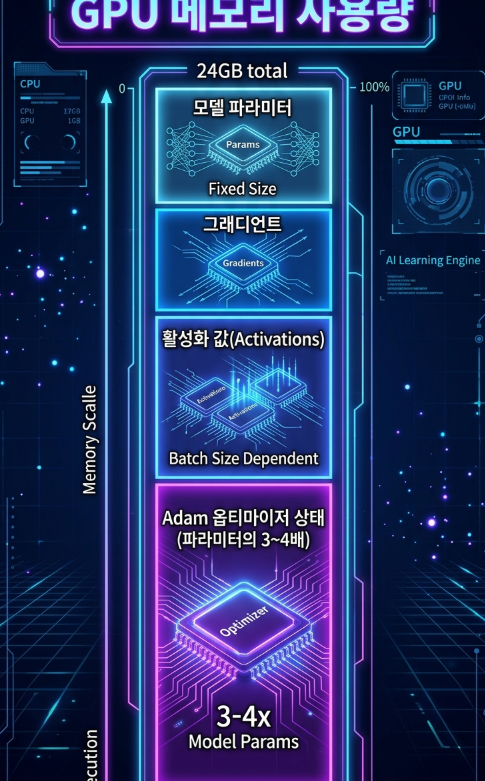


**14.1.2 OOM (Out of Memory) — 딥러닝 엔지니어의 성인식**

GPU 메모리 부족 오류는 누구나 겪습니다. 당황하지 말고 다음 4단계 순서로 대응하세요:

**1단계 — 정밀도 낮추기**: `precision="16-mixed"`. 메모리를 거의 절반으로 줄이면서 속도도 빨라지는 "공짜 점심"입니다.

**2단계 — 배치 사이즈 줄이기**: 가장 직관적이지만, 너무 작아지면 학습이 불안정해집니다.

**3단계 — 그래디언트 축적**: `accumulate_grad_batches=4`로 설정하면, 물리적으로는 작은 배치를 돌리지만 수학적으로는 4배 큰 배치를 사용하는 효과를 냅니다. 배치 사이즈를 줄여서 발생하는 학습 불안정을 보상할 수 있습니다.

**4단계 — 그래디언트 체크포인팅**: 순전파 중간 결과(활성화 값)를 저장하지 않고, 역전파 시 필요할 때 재계산합니다. 메모리를 속도와 교환하는 기법입니다. PyTorch에서는 `torch.utils.checkpoint.checkpoint` 함수로, 또는 Lightning에서 `Trainer(strategy=...)`의 일부로 활용 가능합니다.

**기억하세요**: OOM의 원인이 모델 파라미터 자체가 아니라 **Adam 옵티마이저의 상태**(파라미터의 3~4배 메모리)인 경우가 매우 흔합니다. 모델 크기가 GPU 메모리의 1/4도 안 되는데 OOM이 발생한다면, 옵티마이저를 의심하세요.

**배치 사이즈 팁**: 2의 거듭제곱(32, 64, 128, 256...)으로 설정하면 GPU 메모리 활용 효율이 더 좋습니다. GPU의 연산 유닛이 2의 거듭제곱 크기에 최적화되어 있기 때문입니다.



**14.1.3 NaN/Inf — 보이지 않는 위협**

모델이 멈추지는 않지만, 값이 조용히 NaN이나 무한대로 변해버리는 현상입니다. 학습 곡선을 보다가 갑자기 Loss가 `nan`으로 표시되면, 이전 몇 스텝에서 이미 그래디언트가 폭주하고 있었던 것입니다.

**진단 워크플로우:**
1. `gradient_clip_val=1.0`으로 그래디언트 크기를 제한하고 다시 실행
2. W&B나 TensorBoard에서 그래디언트 노름(Norm)을 모니터링 — NaN 직전에 스파이크가 보이는지 확인
3. 스파이크가 보인다면 → 학습률을 낮추거나, 그래디언트 클리핑 값을 더 낮게 설정
4. 스파이크 없이 갑자기 NaN → 모델 아키텍처나 초기화에 문제

**흔한 원인들:**
- **BatchNorm/LayerNorm**: 정규화 레이어는 수치적 불안정의 대표적 원인입니다. 배치가 너무 작으면 BatchNorm의 분산 추정이 불안정해집니다.
- **16비트 정밀도의 한계**: FP16은 표현 가능한 값의 범위가 좁아, 매우 작은 값이 0으로 수렴(Underflow)하거나 큰 값이 무한대로 발산(Overflow)하기 쉽습니다. 임시로 32비트로 전환해보세요 — 문제가 해결되면 수치 정밀도 이슈입니다. BF16은 FP16보다 Dynamic Range가 넓어 이 문제가 덜합니다.
- **학습률이 너무 높음**: 가장 단순하고 흔한 원인입니다. 학습률을 10배 낮춰보세요.

**실서비스 사례 — Dolly 프로젝트의 그래디언트 스파이크**: Databricks의 Dolly Mini 모델 학습 중, 특정 시점에서 갑자기 그래디언트 노름이 1000배 이상 치솟는 현상이 관찰되었습니다. 원인은 LayerNorm 직후의 연산에서 수치적 불안정이 발생한 것이었고, 그래디언트 클리핑과 BF16으로의 전환으로 해결되었습니다.



### 14.2 2단계: Make it Fast — 추측이 아니라 측정으로

모델이 구동되면, 다음은 실험 주기를 단축하는 것입니다. **하루에 1번 실험하는 팀과 10번 실험하는 팀 사이에는 넘을 수 없는 생산성 차이**가 있습니다.



**14.2.1 직감에 반하는 딥러닝 성능**

최적화 전에, 여러분의 직감이 얼마나 틀릴 수 있는지 먼저 인식해야 합니다:

- **Transformer에서 Attention이 가장 느릴까?** 실제로 프로파일링해 보면, 많은 설정에서 단순한 MLP 컴포넌트가 더 많은 시간을 차지합니다. FlashAttention 같은 최적화가 Attention에 이미 적용되어 있기 때문입니다.
- **GPU 메모리의 가장 큰 소비자는?** 모델 파라미터가 아닙니다. Adam 옵티마이저 상태, 활성화 값(Activation), 그래디언트가 각각 파라미터와 비슷하거나 더 큰 메모리를 차지합니다.
- **학습의 가장 무거운 작업은?** 순전파/역전파가 아닐 수 있습니다. 적절한 병렬화가 없는 데이터 로딩이 실제 연산 시간을 압도하는 경우가 매우 흔합니다.

이런 의외성 때문에 **추측만으로 최적화하면 안 됩니다.** 직접 프로파일링해야 합니다.

**14.2.2 프로파일링 실전**

In [ ]:
# Lightning 프로파일러 — 가장 쉬운 시작점
trainer = pl.Trainer(profiler="simple", max_epochs=1)
trainer.fit(model, datamodule=data)

출력 예시:

```
Action                  | Mean (s)  | Total (s) | Percentage
---------------------------------------------------------------
run_training_epoch      | 12.5      | 12.5      | 100%
  training_step         | 0.08      | 8.0       | 64%
  get_train_batch       | 0.04      | 4.0       | 32%
  optimizer_step        | 0.005     | 0.5       | 4%
```

**이 결과를 읽는 법:**
- `get_train_batch`(데이터 로딩)가 32%? → 모델을 아무리 빠르게 해도 32%의 한계가 있음. `num_workers`부터 늘려야 합니다.
- `training_step`이 64%? → 모델 연산 자체가 주 병목. 혼합 정밀도, `torch.compile`, 또는 모델 경량화를 시도하세요.
- `optimizer_step`이 40% 이상? → 옵티마이저가 병목. AdamW에서 SGD로의 전환이나, 분산 학습 시 All-Reduce 통신 최적화를 검토하세요.

더 정밀한 분석이 필요하면 `profiler="advanced"`(Python cProfile 기반)이나 PyTorch의 `torch.profiler`를 사용하세요.



**14.2.3 암달의 법칙(Amdahl's Law) — 최적화의 황금률**

시스템의 전체 속도 향상은 **개선된 부분의 비율**에 의해 제한됩니다. 데이터 로딩이 전체 시간의 90%를 차지한다면, 모델 연산을 100배 빠르게 만들어도 전체 성능 향상은 10% 미만입니다. **비중이 가장 큰 병목부터 공략해야 합니다.**



**14.2.4 속도 최적화 실전 체크리스트 (순서대로 시도하세요)**

1. **데이터 로딩 최적화**: `num_workers` 증가, `persistent_workers=True`, `pin_memory=True`, 데이터를 NVMe SSD에 배치
2. **혼합 정밀도**: `precision="16-mixed"` — 거의 항상 적용해야 합니다
3. **`torch.compile(model)`**: 커널 퓨전으로 20~50% 속도 향상 가능
4. **그래디언트 축적으로 효과적 배치 증가**: 큰 배치는 GPU 활용률을 높입니다
5. **불필요한 로깅/시각화 제거**: 매 스텝마다 텐서를 CPU로 가져오는 로깅은 놀라울 정도로 큰 오버헤드를 발생시킵니다. `self.log()`의 `on_step=False, on_epoch=True`를 활용하세요
6. **분산 학습**: 데이터 병렬화(DDP)로 GPU를 추가

**실서비스 사례 — 데이터 로딩이 병목이었던 경우**: 한 ML 팀이 이미지 분류 모델의 학습 시간을 줄이기 위해 A100으로 GPU를 업그레이드했는데, 속도가 거의 개선되지 않았습니다. 프로파일링 결과, 전체 시간의 70%가 JPEG 디코딩(데이터 전처리)에 소요되고 있었습니다. GPU는 이미 빠르게 연산을 끝내고 CPU가 다음 배치를 준비할 때까지 놀고 있었던 것입니다. NVIDIA DALI로 GPU 기반 디코딩으로 전환한 후 학습 속도가 3배 향상되었습니다. GPU를 바꾸기 전에 프로파일링을 먼저 하세요.

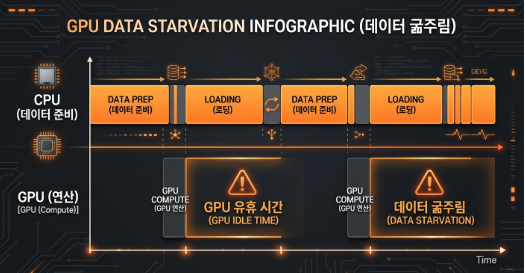



**"데이터 굶주림(Data Starvation)" 현상의 진단과 해결**

GPU는 초당 수조 번의 연산을 수행할 수 있지만, CPU가 데이터를 충분히 빨리 공급하지 못하면 GPU는 놀게 됩니다. 이것이 "데이터 굶주림" 현상입니다.

진단법: 프로파일러에서 `get_train_batch` 시간이 `training_step`보다 현저히 길다면, GPU가 CPU를 기다리고 있는 것입니다. `nvidia-smi`로 GPU 활용률을 확인했을 때 30~50% 수준이라면 높은 확률로 데이터 굶주림입니다.

해결 체크리스트 (효과가 큰 순서대로):
1. `num_workers` 증가: CPU 코어 수의 절반~전체 사이에서 실험적으로 조정. 너무 높이면 오히려 IPC 오버헤드가 발생
2. `persistent_workers=True`: 에포크 사이에 워커 프로세스를 재사용하여 초기화 비용 제거
3. `pin_memory=True`: CPU → GPU 데이터 전송을 비동기(non-blocking)로 수행
4. 데이터를 NVMe SSD에 배치: Day 2에서 배운 스토리지 지연 시간 차이를 떠올리세요
5. 전처리를 사전 캐싱: 무거운 전처리(토크나이징, 리사이징 등)를 학습 전에 미리 수행하여 `.pt` 또는 `.arrow` 파일로 저장
6. GPU 기반 전처리: NVIDIA DALI 또는 `torchvision.transforms.v2`(GPU 지원)를 활용

```python
# 데이터 굶주림 진단 코드
import time

def measure_data_loading_speed(dataloader, num_batches=50):
    """DataLoader의 배치 공급 속도를 측정"""
    start = time.time()
    for i, batch in enumerate(dataloader):
        if i >= num_batches:
            break
    elapsed = time.time() - start
    batches_per_sec = num_batches / elapsed
    print(f"DataLoader 속도: {batches_per_sec:.1f} batches/sec ({elapsed:.1f}s for {num_batches} batches)")
    print(f"→ GPU가 배치당 0.05초 걸린다면, 필요한 공급 속도는 20 batches/sec")
    return batches_per_sec
```

### 14.3 3단계: Make it Right — 성능을 끌어올리는 과학

모델이 구동되고 빨라졌으면, 이제 검증/테스트 메트릭을 목표치까지 끌어올립니다.


**14.3.1 성능 저하의 3가지 원인과 처방**

이 표를 머릿속에 항상 갖고 있으세요. 성능이 안 나올 때 첫 번째 할 일은 train_loss와 val_loss를 비교하는 것입니다.

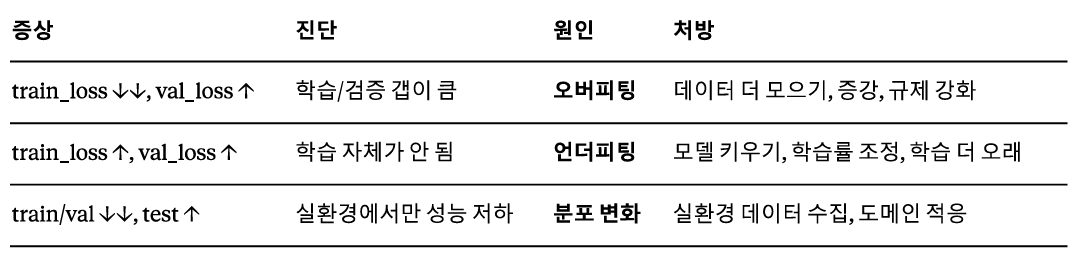


**14.3.2 스케일링 법칙(Scaling Laws)의 실전 활용**

과거에는 "성능을 올리려면 무엇을 해야 하지?"가 직감의 영역이었습니다. 이제는 **수학적으로 예측**할 수 있습니다.

핵심 원리: 모델 성능(Loss)은 **연산 예산(Compute), 데이터셋 크기, 파라미터 수**라는 세 축에 따라 거듭제곱 법칙(Power Law)으로 향상됩니다. 로그-로그 스케일에서 직선으로 나타납니다.

**실전 활용법 — 3단계:**
1. **작은 규모 실험 3~5개 수행**: 파라미터 수나 데이터 크기를 점진적으로 늘리며 각각의 최종 Loss를 기록합니다.
2. **로그-로그 차트에 점을 찍고 직선 회귀**: x축은 자원(compute/data/params), y축은 Loss.
3. **직선을 연장하여 필요 자원 추산**: "목표 Loss에 도달하려면 데이터가 10배, GPU 시간이 5배 필요하다"라는 구체적인 숫자를 얻습니다.

이것이 바로 OpenAI, Google DeepMind 같은 선도 팀들이 학습을 언제 멈출지, 모델을 얼마나 크게 만들지를 결정하는 방식입니다. "실험을 10배 돌리면 성능이 X% 향상될까?"에 데이터 기반으로 답할 수 있게 됩니다.

**Chinchilla Scaling**: DeepMind의 연구에 따르면, 많은 모델이 파라미터 수에 비해 데이터가 부족한 상태로 학습됩니다. 성능 최적화를 위해서는 파라미터 수와 데이터 양을 **균형 있게** 늘려야 합니다. 파라미터만 키우고 데이터를 그대로 두면 비용 대비 성능 향상이 매우 비효율적입니다.

>

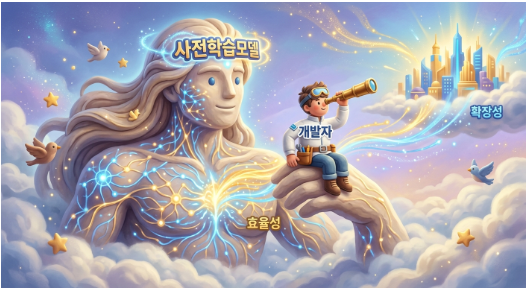

**14.3.3 비용 한계와 대안: Foundation Model 활용**  

모든 팀이 무한정 스케일을 키울 수는 없습니다. 비용이 문제라면:

1. **이미 대규모로 사전 학습된 Foundation Model을 가져와 Fine-tuning하세요.** 이것이 Day 1에서 배운 "거인의 어깨 위에 올라타기"입니다.

2. **검증된 아키텍처와 하이퍼파라미터를 고수하세요.** 독자적인 아키텍처를 밑바닥부터 설계하는 것은 매우 위험합니다. Hugging Face Hub이나 Papers with Code에서 이미 작동이 증명된 설정을 가져오세요.  

**3. HPO보다 스케일링이 우선입니다.** 안정적인 베이스라인을 확보하고 스케일링 법칙에 따라 자원을 집중하는 것이, 하이퍼파라미터를 미세 조정하는 것보다 성공률이 높습니다.



실서비스 사례 — **스케일링으로 해결한 추천 시스템**: 한 이커머스 기업이 클릭률 예측 모델의 성능을 높이기 위해 3개월간 아키텍처를 수정하고 하이퍼파라미터를 튜닝했지만, AUC가 0.2% 향상에 그쳤습니다. 그런데 학습 데이터의 기간을 3개월 → 12개월로 늘리자 AUC가 1.5% 향상되었습니다. 엔지니어링 노력 3개월의 7.5배 효과를 데이터 스케일링 하나로 달성한 것입니다.

**✅ Chapter 14 체크포인트**
> 1. "Make it Run → Make it Fast → Make it Right" 순서에서, 왜 ML에서는 "Fast"가 "Right"보다 먼저 와야 하는지 설명할 수 있으신가요?
> 2. OOM 오류를 해결하는 4단계 전략을 순서대로 말할 수 있으신가요? Adam이 파라미터의 3~4배 메모리를 쓰는 이유는 무엇인가요?
> 3. 프로파일링 결과에서 `get_train_batch`가 전체 시간의 60%를 차지한다면, 어떤 최적화를 우선 시도하시겠어요? 반대로 `training_step`이 90%라면요?
> 4. 스케일링 법칙의 "작은 실험 → 직선 외삽 → 필요 자원 추산" 흐름을 자신의 언어로 설명하고, 이것이 비즈니스적으로 어떤 가치를 주는지 설명해 보세요.
> 5. 성능 저하 진단표(오버피팅/언더피팅/분포 변화)에서, 자신의 최근 프로젝트가 어떤 상황이었는지 분석하고 적절한 처방을 매칭해 보세요.

---


**✅ Chapter 14 체크포인트**
1. "Make it Run → Make it Fast → Make it Right" 순서에서, 왜 ML에서는 "Fast"가 "Right"보다 먼저 와야 하는지 설명할 수 있으신가요?
  - 전통적인 소프트웨어 개발에서는 로직의 정확성(Right)을 먼저 확보한 뒤 병목을 찾아 최적화(Fast)하는 것이 정석입니다. 하지만 머신러닝에서는 이 순서가 뒤바뀝니다.

    - 실험 주기가 곧 모델의 품질: ML에서 모델이 'Right(목표 정확도 달성 및 일반화)'한지 확인하려면 전체 데이터셋을 수십~수백 번 반복 학습해야 합니다. 코드가 아무리 완벽해도 1 Epoch를 도는 데 일주일이 걸린다면, 하이퍼파라미터 튜닝이나 아키텍처 변경 같은 '실험' 자체를 할 수 없습니다.
    - 즉, 빠른 반복(Fast Iteration)이 보장되어야만 실패를 빠르게 겪고 모델의 성능을 올바른 방향(Right)으로 튜닝할 수 있기 때문입니다.

2. OOM 오류를 해결하는 4단계 전략을 순서대로 말할 수 있으신가요? Adam이 파라미터의 3~4배 메모리를 쓰는 이유는 무엇인가요?
  - GPU 메모리 초과(OOM)는 ML 엔지니어의 숙적입니다. 보통 다음 4단계로 점진적인 해결을 시도합니다.

    - 배치 크기 축소 (Reduce Batch Size): 가장 직관적이고 쉬운 방법입니다. batch_size를 절반으로 줄이며 메모리에 들어가는지 확인합니다.

    - 그래디언트 누적 (Gradient Accumulation): 배치 크기를 줄이면 학습이 불안정해질 수 있습니다. 이를 보완하기 위해 작은 배치로 여러 번 계산한 그래디언트를 누적(Accumulate)한 뒤 한 번에 가중치를 업데이트하여 논리적으로 큰 배치를 쓴 것과 같은 효과를 냅니다.

    - 혼합 정밀도 학습 (Mixed Precision): 32비트 부동소수점(FP32)을 16비트(FP16 또는 BF16)로 낮춰 메모리 사용량을 절반으로 줄이고 텐서 코어(Tensor Core)를 활용해 연산 속도를 높입니다.

    - 메모리 오프로딩 및 체크포인팅 (Offloading & Gradient Checkpointing): 1~3단계로도 안 되면, 순전파 때 활성화(Activation) 값을 저장하지 않고 역전파 때 재계산(Checkpointing)하거나, 옵티마이저 상태를 CPU 메모리로 잠시 넘기는(Offloading) 고급 기법을 사용합니다.

  - Adam 옵티마이저가 메모리를 3-4배 먹는 이유
  단순히 모델의 파라미터(Weight)만 저장하는 것이 끝이 아닙니다. Adam은 파라미터 업데이트를 위해 기울기(Gradient)는 물론, 각 파라미터별 1차 모멘텀(평균)과 2차 모멘텀(분산) 상태를 모두 추적하고 메모리에 유지해야 합니다. 모델 파라미터 크기가 1GB라면, Adam 상태를 유지하는 데만 최소 3-4GB의 추가 메모리가 예약됩니다.

3. 프로파일링 결과에서 `get_train_batch`가 전체 시간의 60%를 차지한다면, 어떤 최적화를 우선 시도하시겠어요? 반대로 `training_step`이 90%라면요?

  - 프로파일링을 통해 병목 구간을 찾았다면 처방도 완전히 달라져야 합니다.
    - get_train_batch가 60%일 때 (I/O 및 데이터 전처리 병목):
    GPU는 연산을 기다리며 놀고 있고, 데이터를 디스크에서 읽어와 증강(Augmentation)하는 과정이 발목을 잡는 상태입니다.
    
    - 우선 시도: DataLoader의 병렬 워커(Worker) 수(num_workers) 늘리기, 이미지나 텍스트 전처리를 미리 수행하여 캐싱하기, NVMe SSD 등 빠른 스토리지 활용 등을 시도합니다.
    
    - training_step이 90%일 때 (Compute 병목):
    데이터는 원활하게 공급되지만 GPU의 연산 자체가 오래 걸리는 상태입니다.
    
    - 우선 시도: 위에서 언급한 Mixed Precision(AMP)을 적용해 연산량 줄이기, torch.compile 같은 JIT 컴파일러로 불필요한 메모리 접근 오버헤드 줄이기, 혹은 모델 아키텍처 경량화를 시도합니다.

4. 스케일링 법칙의 "작은 실험 → 직선 외삽 → 필요 자원 추산" 흐름을 자신의 언어로 설명하고, 이것이 비즈니스적으로 어떤 가치를 주는지 설명해 보세요.

  - 스케일링 법칙은 "작은 데이터와 모델로 얻은 실험 결과를 바탕으로, 컴퓨팅 자원을 얼마나 더 투입해야 목표 성능에 도달할지 예측하는 수학적 흐름"입니다. 작은 스케일에서의 모델 손실(Loss) 하락 추세를 로그(Log) 그래프로 그리면 직선(선형)으로 나타나는데, 이 직선을 주욱 그어보면(외삽, Extrapolation) 거대 모델의 성능을 예측할 수 있습니다.

    - 비즈니스적 가치 (ROI 예측): 경영진이나 스테이크홀더 입장에서는 "정확도 2%를 올리기 위해 GPU 100장이 더 필요합니다"라는 막연한 요구를 승인하기 어렵습니다. 스케일링 법칙을 활용하면 "정확도를 $X$만큼 개선하려면 $Y$만큼의 컴퓨팅 예산과 데이터가 필요하며, 한계 효용이 체감되는 지점은 여기입니다"라는 데이터 기반의 예산 기획과 리스크 관리가 가능해집니다.

5. 성능 저하 진단표(오버피팅/언더피팅/분포 변화)에서, 자신의 최근 프로젝트가 어떤 상황이었는지 분석하고 적절한 처방을 매칭해 보세요.

  - ML 시스템의 성능 진단은 크게 3가지 축(Train Loss, Validation Loss, Production Metric)을 비교하여 수행합니다.
  - 유통 시스템의 백엔드에서 기존의 규칙 기반 로직을 대체할 '상품 수요 예측 AI 모델'을 개발해 배포하는 상황을 가정해 보겠습니다.

    - Underfitting (과소적합): Train Loss조차 떨어지지 않음. (모델이 너무 단순하거나 유의미한 피처가 없음)
      - 처방: 모델의 파라미터를 늘리거나, 날씨, 휴일 여부 등 새로운 피처를 추가합니다.
    - Overfitting (과적합): Train Loss는 낮지만 Validation Loss가 높음.
      - 처방: 특정 상품의 과거 판매량만 외워버린 상태입니다. Dropout을 추가하거나 학습 데이터를 더 수집(혹은 증강)하여 일반화 능력을 키워야 합니다.

    - Distribution Shift (데이터 분포 변화): Validation까지 완벽히 통과했는데, 실제 Production 시스템에 붙였더니 예측이 다 빗나가는 상황.
      - 상황 분석: 과거 5년 치의 잘 정제된 데이터로 테스트를 통과했지만, 최근 급격한 소비 트렌드 변화나 경쟁사의 파격적인 할인 행사 같은 새로운 패턴이 발생한 것입니다.

      - 처방: 모델 자체의 결함이 아니라 '세계'가 변한 것이므로, 최근 1~2개월의 데이터를 가중치를 두어 파인튜닝(재학습)하거나, 예측값이 튀는 것을 막기 위해 기존 백엔드의 룰베이스 로직을 안전망(Fallback)으로 결합하는 MLOps 파이프라인 보완이 필요합니다.


## Chapter 15. LLM 시대의 평가와 모니터링



### 15.1 전통적 메트릭의 한계

여러분이 학습한 분류 모델은 Accuracy, Precision, Recall, F1으로 평가할 수 있었습니다. 하지만 LLM 기반 시스템(RAG, Agent, 챗봇 등)은 이런 단일 숫자 메트릭으로 성능을 포착하기 어렵습니다.

"이 답변이 정확한가?"뿐 아니라:
- 답변이 자연스러운가? (유창성, Fluency)
- 환각(Hallucination)은 없는가? (사실성, Faithfulness)
- 톤이 적절한가? (스타일, Tone)
- 근거 문서를 정확히 참조하고 있는가? (RAG의 경우, Attribution)
- 사용자의 의도를 정확히 파악했는가? (의도 이해, Intent Understanding)
- 유해하거나 편향된 내용을 포함하고 있지 않은가? (안전성, Safety)

이 모든 차원을 하나의 숫자로 요약하면, 각 차원에서 어디가 약한지 알 수 없습니다. 예를 들어, "정확하지만 딱딱한 답변"과 "자연스럽지만 환각이 섞인 답변" 중 어떤 것이 더 나은지는 비즈니스 맥락에 따라 다릅니다.



### 15.2 2026년의 평가 전략 — 다층적 접근



**Layer 1: 자동 메트릭 (가장 빠르고 저렴)**

여전히 유용한 자동 메트릭들이 있습니다:
- BLEU/ROUGE: 참조 답변과의 단어 겹침 측정. 빠르지만 의미적 유사성을 놓칩니다.
- BERTScore: 사전 학습된 BERT 임베딩으로 의미적 유사성 측정. BLEU보다 인간 판단과 상관관계가 높습니다.
- 정확 일치(Exact Match): 정답이 명확한 QA 태스크에 유용.
- Perplexity: 언어 모델 자체의 품질 지표.



**Layer 2: LLM-as-a-Judge (중간 비용, 빠른 반복)**

GPT-4o나 Claude 같은 강력한 LLM을 평가자로 활용합니다. 평가 기준을 프롬프트로 정의하고, 모델 출력의 품질을 자동 채점합니다.

```python
evaluation_prompt = """
다음 사용자 질문과 시스템 답변을 평가하세요.

질문: {question}
답변: {answer}
참조 문서: {context}

다음 각 항목을 1-5점으로 채점하고, 이유를 한 줄로 설명하세요:
1. 정확성: 답변이 참조 문서의 내용과 일치하는가?
2. 완전성: 질문에 필요한 정보를 빠짐없이 포함하는가?
3. 유창성: 한국어로 자연스럽게 읽히는가?
4. 환각 여부: 참조 문서에 없는 내용을 만들어낸 부분이 있는가?

JSON 형식으로 응답하세요.
"""
```

**장점**: 인간 평가보다 10~100배 빠르고 저렴. 인간 평가와의 상관관계가 0.7~0.9로 높음.
**주의점**: 평가 LLM 자체의 편향(예: 길이 편향 — 긴 답변에 더 높은 점수를 주는 경향)에 유의하세요. 평가 프롬프트에 "길이에 관계없이 핵심만 평가하라"는 지시를 포함하는 것이 좋습니다.

**Layer 3: Human Evaluation (가장 신뢰, 가장 비쌈)**

소량의 핵심 샘플에 대해 전문가 평가를 수행합니다. LLM-as-a-Judge의 결과를 교차 검증하고, 자동 메트릭으로 포착되지 않는 미묘한 문제를 발견합니다.

실무 팁: 주 1회 또는 모델 업데이트 시 50~100개 샘플에 대해 인간 평가를 수행하고, 이를 LLM-as-a-Judge의 교정(Calibration) 데이터로 활용하세요.

**Layer 4: 골든 세트(Golden Set)와 회귀 테스트**

도메인에 맞는 평가 데이터셋을 직접 구축합니다. 모델이 변경될 때마다 이 세트에 대한 성능을 확인하여 회귀(Regression)를 방지합니다.

```python
# golden_set.json — 직접 큐레이션한 핵심 평가 케이스
[
    {"question": "반품 정책이 어떻게 되나요?",
     "expected_key_points": ["30일 이내", "영수증 필요", "환불"],
     "category": "정책 문의"},
    {"question": "제품 X의 배터리 수명은?",
     "expected_answer_contains": "10시간",
     "category": "제품 정보"},
]
```

**실서비스 사례 — Airbnb의 LLM 평가 파이프라인**: Airbnb는 고객 지원 챗봇을
LLM으로 전환하면서, 4계층 평가 시스템을 구축했습니다. (1) 자동 메트릭(응답 시간, 길이, 기본 문법), (2) LLM-as-a-Judge로 정확성·안전성 평가, (3) 주 100건의 인간 평가, (4) 1,000건의 골든 세트 회귀 테스트. 이 시스템 덕분에 모델 업데이트 주기를 월 1회에서 주 2회로 단축하면서도 품질 저하를 방지할 수 있었습니다.

**Layer 5: A/B 테스트 (비즈니스 메트릭 기준)**

최종적으로는 실제 사용자에게 두 버전을 동시에 노출하여 비즈니스 메트릭(클릭률, 전환율, 체류 시간, NPS 등)으로 판단합니다. 기술적 메트릭(정확도)이 아무리 좋아도 비즈니스 메트릭이 개선되지 않으면 의미가 없습니다. 후속 MLOps 과정에서 자세히 다룹니다.

**평가 계층 간 관계 — 어떤 상황에서 어떤 계층을 쓰는가**


| 상황 | 적합한 계층 | 빈도 |
| :--- | :--- | :--- |
| 코드 커밋마다 자동 확인 | Layer 1 (자동 메트릭) + 골든 세트 | 매 PR |
| 모델 업데이트 후 품질 확인 | Layer 2 (LLM-as-a-Judge) | 주 1~2회 |
| 새 모델 버전 출시 전 최종 검증 | Layer 3 (Human eval) | 월 1~2회 |
| 비즈니스 임팩트 검증 | Layer 5 (A/B 테스트) | 분기 1~2회 |


핵심 원칙: **빈번한 계층은 자동화되어야 하고, 드문 계층은 심도가 깊어야 합니다.** 매일 인간 평가를 수행하는 것은 비용 측면에서 불가능하고, A/B 테스트만으로 모든 품질을 판단하는 것은 피드백 루프가 너무 느립니다.

**실전 예시 — RAG 시스템의 환각(Hallucination) 평가 파이프라인**

여러분이 RAG를 실습하면서 경험했을 문제 중 하나는 "모델이 검색된 문서에 없는 내용을 만들어내는 것(환각)"입니다. 이것을 체계적으로 평가하는 방법을 코드로 보겠습니다.

```python
def evaluate_rag_faithfulness(question, retrieved_docs, model_answer, judge_llm):
    """RAG 답변이 검색된 문서에 근거하는지 평가"""

    prompt = f"""
    당신은 RAG 시스템의 답변 품질을 평가하는 심사위원입니다.

    [사용자 질문]
    {question}

    [검색된 참조 문서]
    {retrieved_docs}

    [시스템 답변]
    {model_answer}

    다음 기준으로 평가하세요:

    1. 충실성(Faithfulness): 답변의 모든 내용이 참조 문서에 근거하는가? (1-5)
       - 5: 모든 주장이 문서에서 직접 확인 가능
       - 3: 대부분 근거 있으나 일부 추론이 포함됨
       - 1: 문서에 없는 내용을 상당 부분 만들어냄 (환각)

    2. 완전성(Completeness): 질문에 답하는 데 필요한 정보를 빠짐없이 포함하는가? (1-5)

    3. 관련성(Relevance): 불필요한 정보 없이 질문에 집중하는가? (1-5)

    각 항목의 점수와 한 줄 이유를 JSON으로 응답하세요.
    """

    result = judge_llm.generate(prompt)
    return parse_json(result)

# 골든 세트에 대해 일괄 평가
def run_rag_evaluation(golden_set, rag_pipeline, judge_llm):
    scores = []
    for case in golden_set:
        docs = rag_pipeline.retrieve(case['question'])
        answer = rag_pipeline.generate(case['question'], docs)
        eval_result = evaluate_rag_faithfulness(
            case['question'], docs, answer, judge_llm
        )
        scores.append({
            'question': case['question'],
            'faithfulness': eval_result['faithfulness'],
            'completeness': eval_result['completeness'],
            'relevance': eval_result['relevance'],
        })

    df = pd.DataFrame(scores)
    print(f"평균 충실성: {df['faithfulness'].mean():.2f}")
    print(f"평균 완전성: {df['completeness'].mean():.2f}")
    print(f"환각 의심 케이스 (충실성 ≤ 2): {(df['faithfulness'] <= 2).sum()}건")
    return df
```

이 평가 파이프라인을 주기적으로 실행하면, 모델 업데이트 후 환각이 증가했는지, 특정 유형의 질문에서 충실성이 낮은지를 체계적으로 추적할 수 있습니다.


```python
import numpy as np
from scipy import stats

def detect_feature_drift(reference_data, production_data, feature_name, threshold=0.05):
    """
    Kolmogorov-Smirnov 검정으로 두 분포의 차이를 감지합니다.

    reference_data: 모델 학습 시점의 피처 값 (예: 학습 데이터의 'age' 컬럼)
    production_data: 현재 운영 중인 피처 값 (예: 오늘 들어온 'age' 값들)
    threshold: p-value 임계값 (이하면 드리프트로 판정)
    """
    ks_stat, p_value = stats.ks_2samp(reference_data, production_data)

    drifted = p_value < threshold
    status = "🚨 드리프트 감지!" if drifted else "✅ 정상"

    print(f"[{feature_name}] KS 통계량={ks_stat:.4f}, p-value={p_value:.4f} → {status}")

    if drifted:
        print(f"  학습 시점: 평균={reference_data.mean():.2f}, 표준편차={reference_data.std():.2f}")
        print(f"  현재 운영: 평균={production_data.mean():.2f}, 표준편차={production_data.std():.2f}")

    return drifted, p_value

# 사용 예시
# 학습 데이터에서 저장해둔 피처 통계
train_ages = np.random.normal(35, 10, 10000)  # 학습 시점: 평균 35세
# 운영 중 수집된 피처
prod_ages = np.random.normal(42, 12, 500)     # 현재: 사용자 연령대가 높아짐!

detect_feature_drift(train_ages, prod_ages, "user_age")
# 출력: [user_age] KS 통계량=0.2315, p-value=0.0000 → 🚨 드리프트 감지!
```


### 15.3 배포 후 모니터링 — 모델은 시간이 지나면 썩는다

Day 1에서 배운 "데이터 드리프트"가 실제로 어떻게 발현되고 모니터링되는지 구체화합니다.


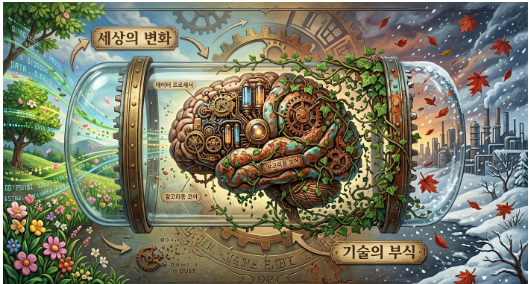

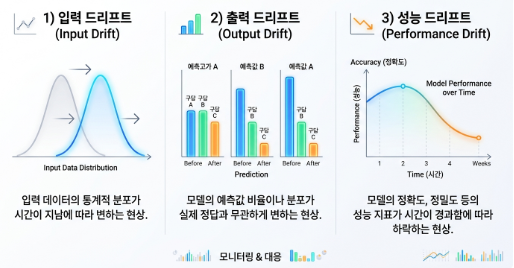


**드리프트의 3가지 유형:**

**입력 드리프트(Input/Feature Drift)**: 모델에 들어오는 데이터의 통계적 분포가 학습 시점과 달라지는 것. 원인: 계절 변화, 사용자 인구통계 변화, 새로운 제품 카테고리 추가, 데이터 수집 파이프라인의 변경 등.

모니터링 방법: 주요 입력 피처의 분포(평균, 분산, 히스토그램)를 학습 시점과 비교하여 KL-Divergence나 Kolmogorov-Smirnov 검정으로 유의미한 변화를 감지합니다.

**출력 드리프트(Prediction Drift)**: 모델의 예측 분포가 변하는 것. 예: 갑자기 특정 클래스를 과도하게 예측하기 시작하거나, 예측 점수의 평균이 크게 이동.

모니터링 방법: 예측 확률 분포의 변화를 추적합니다. "어제까지 긍정:부정 = 60:40이었는데 오늘 갑자기 90:10이다"면 뭔가 이상한 것입니다.

**성능 드리프트(Performance/Concept Drift)**: 실제 정답(Ground Truth)을 확보할 수 있는 경우, 시간에 따른 성능 변화를 직접 추적. 가장 확실하지만, Ground Truth 확보에 시간이 걸리는 경우가 많습니다(예: 대출 부도 여부는 수개월 뒤에나 알 수 있음).

**자동 알림이 핵심입니다**: "어제까지 95%였던 정확도가 오늘 80%로 떨어졌다"를 사람이 수동으로 대시보드를 확인해야 알게 된다면 너무 늦습니다. 임계값을 설정하고, 넘어서면 Slack/이메일로 알림이 가는 시스템이 필요합니다.

**모니터링 도구 생태계 (2026년):**
- **Evidently AI**: 오픈소스. 데이터 드리프트 감지, 모델 성능 추적을 위한 대시보드 제공.
- **WhyLabs**: 실시간 데이터/모델 모니터링 SaaS.
- **W&B**: 실험 관리와 배포 후 모니터링을 하나의 도구로.
- **Custom**: Prometheus + Grafana로 직접 구축 (후속 MLOps 과정에서 실습).

**드리프트 감지 실전 코드**: 간단한 통계 기반 드리프트 감지를 직접 구현해 봅시다. 실무에서는 이런 로직을 모니터링 도구에 내장하거나 정기 배치잡으로 실행합니다.

**드리프트 감지 후 대응 전략**: 드리프트가 감지되었다고 해서 항상 즉시 재학습해야 하는 것은 아닙니다. 상황에 따른 대응:


| 드리프트 정도 | 성능 영향 | 대응 |
| :--- | :--- | :--- |
| 미미한 드리프트 | 성능 변화 없음 | 관찰만 (다음 정기 재학습 시 반영) |
| 중간 드리프트 | 성능 약간 저하 | 재학습 스케줄 앞당기기 |
| 심한 드리프트 | 성능 급락 | 즉시 재학습 트리거, 필요 시 이전 모델로 롤백 |
| 갑작스러운 변화 | 예측 불가 | 데이터 파이프라인 이상 점검 먼저 (버그일 수 있음) |


특히 "갑작스러운 변화"는 실제 드리프트가 아니라 데이터 파이프라인의 버그일 수 있습니다. 예를 들어 데이터 소스의 API가 변경되어 필드 이름이 바뀐 경우, 드리프트처럼 보이지만 실제로는 코드 수정이 필요한 상황입니다. 따라서 드리프트 알림이 울리면, **"진짜 세상이 변한 것인가, 아니면 우리 파이프라인이 깨진 것인가?"**를 먼저 구분해야 합니다.

**실서비스 사례 — Uber의 실시간 드리프트 감지**: Uber는 수천 개의 ML 모델을 운영하면서, 각 모델에 대해 입력 피처 분포와 예측 분포를 실시간으로 모니터링합니다. 특정 모델의 예측 분포가 학습 시점 대비 유의미하게 변하면 자동으로 재학습 파이프라인이 트리거됩니다. 이 시스템 덕분에 수천 개의 모델을 사람이 일일이 확인하지 않아도 됩니다.

**실서비스 사례 — Spotify의 계절적 드리프트 대응**: Spotify의 음악 추천 모델은 크리스마스 시즌에 특유의 드리프트를 경험합니다. 평소에는 사용자의 장기적 취향을 반영하지만, 12월이 되면 갑자기 캐롤과 파티 음악의 소비가 급증합니다. Spotify는 이런 **예측 가능한 계절적 드리프트**에 대해 별도의 모델을 미리 준비해두고, 시즌에 맞춰 전환하는 전략을 사용합니다.



### 15.4 LLM 특화 모니터링 — 전통 모델과 다른 점

LLM 기반 시스템(RAG, Agent 등)은 전통적인 ML 모델과 모니터링 방식이 달라야 합니다.

**프롬프트 품질 모니터링**: 사용자 입력(프롬프트)의 분포 변화를 추적합니다. 갑자기 특정 유형의 질문이 급증하면, 모델이 그 유형에 대해 충분히 학습되지 않았을 수 있습니다.

**환각(Hallucination) 감지**: RAG 시스템에서 모델의 답변이 검색된 문서에 근거하는지 자동으로 검증합니다. 답변의 각 문장에 대해 "이 문장이 참조 문서에서 지지되는가?"를 LLM-as-a-Judge로 평가할 수 있습니다.

**비용 모니터링**: LLM API는 토큰당 비용이 발생합니다. 특정 사용자가 비정상적으로 긴 프롬프트를 반복적으로 보내거나, 모델이 불필요하게 긴 응답을 생성하고 있지 않은지 모니터링합니다.

**지연시간(Latency) 모니터링**: LLM은 전통 모델보다 추론 시간이 길고 변동이 큽니다. P50(중앙값), P95, P99 지연시간을 추적하고, SLA(Service Level Agreement)를 충족하는지 확인합니다.



> **✅ Chapter 15 체크포인트**
> 1. LLM 기반 시스템을 Accuracy만으로 평가할 수 없는 이유를 설명하고, 추가로 필요한 평가 차원을 5가지 나열할 수 있으신가요?
> 2. LLM-as-a-Judge의 장점과 주의할 한계(편향)를 각각 설명하고, 편향을 완화하는 방법을 하나 제안해 보세요.
> 3. 입력 드리프트, 출력 드리프트, 성능 드리프트의 차이를 각각 한 문장으로 설명하고, 자신의 프로젝트에서 가장 가능성 높은 드리프트 유형은 무엇인지 분석해 보세요.
> 4. "모델은 시간이 지나면 썩는다"는 말의 의미를 코로나19 같은 구체적 사례로 설명할 수 있으신가요? 이를 방지하기 위해 어떤 시스템이 필요한가요?

---


**✅ Chapter 15 체크포인트**
1. LLM 기반 시스템을 Accuracy만으로 평가할 수 없는 이유를 설명하고, 추가로 필요한 평가 차원을 5가지 나열할 수 있으신가요?

  - 기존의 분류 모델(Classifier)은 정답이 'A' 아니면 'B'로 딱 떨어지기 때문에 Accuracy 측정이 가능했습니다. 하지만 LLM은 '열린 생성(Open-ended Generation)'을 합니다. 같은 의미의 정답이라도 수천 가지 문장으로 다르게 표현될 수 있으므로, 단순한 일치 여부(Accuracy)로는 품질을 담아낼 수 없습니다.

  - 추가로 필요한 5가지 평가 차원:
    - 사실성 (Factuality / Groundedness)
      - 답변에 환각(Hallucination)이 없는가?
      - 주어진 컨텍스트(문서)에 기반하여 답변했는가?
    - 유용성 및 관련성 (Relevance / Helpfulness)
      - 사용자의 실제 의도를 파악하고, 질문에 직접적으로 도움이 되는 정보를 제공했는가?
    - 유창성 (Fluency / Coherence)
      - 문법적으로 자연스럽고, 문맥이 끊기지 않으며 논리적으로 일관성이 있는가?
    - 안전성 (Safety / Toxicity)
      - 편향되거나, 공격적이거나, 유해한 내용(예: 개인정보 유출, 욕설)을 생성하지 않는가?
    - 어조와 형식 (Tone & Style)
      - 서비스 성격에 맞는 말투(예: 정중한 CS 톤)를 유지하고, 지시한 포맷(예: JSON, 불릿 포인트)을 잘 지켰는가?

2. LLM-as-a-Judge의 장점과 주의할 한계(편향)를 각각 설명하고, 편향을 완화하는 방법을 하나 제안해 보세요.

    - 앞서 평가 전략 자료에서처럼, LLM을 평가자로 사용하는 것은 실무에서 필수적인 선택이 되었습니다.
    - 장점: 인간 평가보다 압도적으로 빠르고 비용이 저렴합니다. 지속적이고 자동화된 평가(CI/CD 파이프라인 연동)가 가능하며, 놀랍게도 잘 세팅된 LLM 심판은 인간의 평가와 높은 상관관계(0.7~0.9)를 보입니다.

    - 주의할 한계 (편향):
      - 길이 편향 (Verbosity Bias): 내용의 질과 상관없이 길고 장황한 답변에 더 높은 점수를 주는 경향이 있습니다.
      - 위치 편향 (Position Bias): 두 답변(A, B)을 비교할 때, 무조건 먼저 제시된 A를 선호하거나 나중에 제시된 B를 선호하는 경향이 있습니다.

    - 편향 완화 방법 제안 (위치 편향 완화):
      - 위치 스와핑(Position Swapping): 프롬프트를 한 번은 "A와 B 중 골라라"로, 또 한 번은 "B와 A 중 골라라"로 두 번 실행합니다. 두 번 모두 같은 답변을 선택했을 때만 결과를 신뢰(일치)하는 것으로 간주하여 평가의 객관성을 높일 수 있습니다.


3. 입력 드리프트, 출력 드리프트, 성능 드리프트의 차이를 각각 한 문장으로 설명하고, 자신의 프로젝트에서 가장 가능성 높은 드리프트 유형은 무엇인지 분석해 보세요.

  - 모델 배포 이후 데이터와 성능이 틀어지는 현상을 세 가지로 나눌 수 있습니다.

    - 입력 드리프트 (Input Drift): 사용자가 모델에 던지는 질문의 내용이나 패턴(분포) 자체가 과거와 달라지는 현상입니다.

    - 출력 드리프트 (Output Drift): 입력은 그대로인데, (특히 OpenAI 등 외부 API를 쓰는 경우) 잠수함 패치 등으로 인해 모델이 뱉어내는 답변의 스타일이나 길이가 예전과 달라지는 현상입니다.

    - 성능 드리프트 (Performance Drift): 입력이나 출력이 변한 결과, 혹은 외부 환경 변화로 인해 CTR(클릭률)이나 정답률 같은 실제 비즈니스 지표가 하락하는 현상입니다.

  - 프로젝트 분석 (쇼핑몰 CS AI / 수요 예측 AI 기준):
    - 가장 발생 가능성이 높은 것은 입력 드리프트(Input Drift)입니다.
  유통업계는 트렌드 변화가 극심합니다. 작년에는 사용자들이 "롱패딩 세탁법"을 물어봤다면, 올해는 "특정 틱톡 바이럴 아이템 재고"나 "새로 바뀐 멤버십 혜택"을 물어볼 것입니다. 이처럼 계절, 유행, 자사의 정책 변화에 따라 사용자의 입력 텍스트 분포는 끊임없이 변동합니다.


4. "모델은 시간이 지나면 썩는다"는 말의 의미를 코로나19 같은 구체적 사례로 설명할 수 있으신가요? 이를 방지하기 위해 어떤 시스템이 필요한가요?

  - 데이터는 그 당시의 '세상'을 캡처한 스냅샷입니다. 세상이 변하면 모델의 지식은 유통기한이 지나버립니다.
    - 코로나19 사례: 2019년 데이터까지만 학습된 유통 수요 예측 모델이나 챗봇이 있다고 가정해 보겠습니다. 이 모델은 "마스크"를 황사철에만 조금 팔리는 물건으로 예측할 것이고, "거리두기", "비대면 배송", "재택근무용 화상장비 폭증"이라는 거대한 소비 패턴의 변화를 전혀 이해하지 못해 엉뚱한 발주를 넣고 오답을 낼 것입니다. 시대상과 개념의 의미(Concept)가 완전히 변했기 때문입니다.

    - 방지를 위한 필수 시스템:
      - 지속적 모니터링 (Continuous Monitoring): 사용자의 입력과 모델의 출력을 로깅하고, 앞서 언급한 드리프트 발생 여부를 대시보드(Layer 1 자동 메트릭)로 추적해야 합니다.
      - RAG (검색 증강 생성) 시스템 강화: 모델 자체를 매번 재학습하는 것은 비효율적이므로, 사내 최신 DB(신상품, 새 정책 등)를 실시간으로 검색해 프롬프트에 끼워 넣어주는 RAG 파이프라인을 구축하여 지식의 최신성을 유지해야 합니다.
      - Human-in-the-loop (HITL) 피드백 루프: 사용자의 '좋아요/싫어요' 데이터나 CS 직원의 수정 이력을 지속적으로 수집하여, 모델의 파인튜닝(또는 골든 세트 업데이트)에 자동으로 반영되는 파이프라인이 필요합니다.


## Chapter 16. 3일간의 여정을 하나로 — Full Stack ML 엔지니어의 로드맵



### 16.1 세 과정의 연결: 배포 → FSDL → MLOps

Day 1의 Introduction에서 그린 그림을 다시 봅시다:


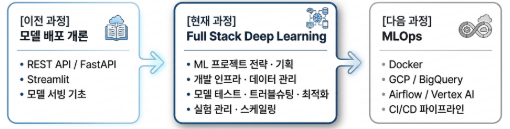


여러분은 이제 "모델을 배포하는 방법"뿐 아니라, **"올바른 문제를 선택하고, 체계적으로 개발하고, 신뢰할 수 있게 테스트하는 방법"** 을 알게 되었습니다. 다음 MLOps 과정에서는 이 모든 것을 자동화된 인프라 위에 올리는 방법을 배웁니다.



### 16.2 Full Stack ML 엔지니어의 핵심 역량 체크리스트

3일간 배운 것을 역량 기준으로 정리합니다:


| 역량 | Day 1 | Day 2 | Day 3 |
| :--- | :--- | :--- | :--- |
| 기획 | ML 도입 판단, 아키타입 선정, PoC 설계 | | |
| 인프라 | | 환경 관리, GPU 선택, 비용 최적화 | |
| 코드 | | Lightning 구조화, HF 활용 | Pytest, 행동 테스트 |
| 데이터 | 플라이휠 설계 | 레이블링, 버전 관리 | 기댓값 테스트 |
| 모델 | Build/Buy/API 판단 | 분산 학습, 혼합 정밀도 | 트러블슈팅 3단계, 스케일링 |
| 평가 | 성공 지표 정의 | 실험 관리(W&B) | LLM 평가, 드리프트 모니터링 |

### 16.3 나만의 Full Stack ML 프로젝트 설계 워크시트
  
3일간 배운 모든 것을 여러분 자신의 프로젝트에 적용해 볼 차례입니다. 아래 워크시트를 직접 채워보세요. 정답이 있는 것이 아닙니다. **"이 프로젝트에 대해 얼마나 명확하게 생각하고 있는가"** 를 스스로 점검하는 과정입니다.  

주제는 자유입니다. 관심 있는 도메인의 실제 문제를 고르세요. 예를 들어 뉴스 분류, 리뷰 감성 분석, 문서 요약, 이미지 분류, 챗봇 등 무엇이든 좋습니다. 단, **transformers** 라이브러리로 사전 학습된 모델을 **Fine-tuning**하는 프로젝트를 권장합니다. 여러분이 이미 갖고 있는 기술 스택을 최대한 활용할 수 있기 때문입니다.

---

#### 📋 Part A. 기획 (Day 1 적용)

```

■ 프로젝트 한 줄 정의
  _______________________________________________________________
  (예: "한국어 뉴스 기사 제목을 7개 카테고리로 자동 분류하는 시스템")

■ ML 도입 판단
  이 문제에 ML이 필요한 이유:
  _______________________________________________________________
  (규칙 기반으로는 왜 한계가 있는지 한 문장으로)

  접근법: [ ] API 호출  [ ] Fine-tuning  [ ] 처음부터 학습
  선택 이유: __________________________________________________

  아키타입: [ ] Software 2.0  [ ] Human-in-the-loop  [ ] Autonomous
  선택 이유: __________________________________________________

■ 성공 메트릭
  비즈니스 메트릭: _____________________________________________
  ML 메트릭: _________________________________________________
  (예: Macro F1 ≥ 0.85, Accuracy ≥ 90%)

■ 데이터
  소스: _______________________________________________________
  규모 (예상): 학습 ______건, 검증 ______건
  레이블 수: ______개
  레이블링 방법: [ ] 이미 있음  [ ] 수동  [ ] 약지도  [ ] 합성 데이터

■ 베이스라인
  ML 이전에 시도할 단순한 방법: _________________________________
  (예: TF-IDF + LogisticRegression, 규칙 기반, 다수결 등)

■ 주요 리스크 (최소 2개)
  1. ___________________________________________________________
  2. ___________________________________________________________
  완화 방법: __________________________________________________

---

#### 📋 Part B. 인프라와 데이터 (Day 2 적용)

```
■ 환경 관리
  가상환경: [ ] venv  [ ] conda  [ ] uv
  의존성 잠금: [ ] pip-compile  [ ] uv lock
  핵심 라이브러리: ____________________________________________
  (예: torch, pytorch-lightning, transformers, datasets, wandb)

■ 모델 선택
  사전 학습 모델: _____________________________________________
  (예: klue/bert-base, beomi/KcELECTRA-base, openai/whisper-small)
  선택 이유: __________________________________________________

■ GPU / 클라우드
  학습 환경: [ ] 로컬 GPU  [ ] Colab  [ ] 클라우드 (__________)  [ ] CPU only
  예상 학습 시간: _____________________________________________

■ 실험 관리
  도구: [ ] W&B  [ ] MLflow  [ ] TensorBoard  [ ] 수동 기록
  추적할 메트릭: ______________________________________________

■ 데이터 기댓값 테스트 (최소 3개 작성)
  1. ___________________________________________________________
  2. ___________________________________________________________
  3. ___________________________________________________________
  (예: "레이블에 결측치가 없어야 함", "텍스트 길이가 2~500자 사이여야 함")

■ 데이터 버전 관리
  현재 레벨: Level ___ (0=무관리, 1=스냅샷, 2=Git LFS, 3=DVC)
  목표 레벨: Level ___
```

---

#### 📋 Part C. 테스트와 품질 (Day 3 적용)

```
■ 암기 테스트
  overfit_batches=1 테스트를 적용할 수 있는가? [ ] Yes  [ ] No
  No라면 이유: ________________________________________________
  10분 이내로 만들기 위해 조정할 것:
  ___________________________________________________________
  (예: 모델 크기 축소, Dropout 제거, 배치 수 감소)

■ 행동 테스트 (최소 2개 설계)
  불변성 테스트 1: 입력을 __________ 바꿔도 결과가 같아야 함
  (예: "쉼표를 추가해도 뉴스 카테고리는 변하지 않아야 함")
  
  불변성/방향성 테스트 2: ______________________________________
  (예: "긍정 키워드를 부정으로 바꾸면 감성 점수가 내려가야 함")

■ 계층적 테스트 배치
  PR 단계 (10분 이내): ________________________________________
  (예: Shape 검증, NaN 검사, 암기 테스트, 린팅)
  
  야간/주간 단계: _____________________________________________
  (예: 전체 검증 데이터 성능 벤치마크, 행동 테스트)

■ 트러블슈팅 계획
  Make it Run — 예상되는 구동 오류: _____________________________
  Make it Fast — 예상 병목: [ ] 데이터 로딩  [ ] 모델 연산  [ ] 기타
  Make it Right — 성능이 안 나올 때 첫 번째 시도:
    [ ] 데이터 더 모으기  [ ] 모델 키우기  [ ] 하이퍼파라미터 조정

■ 평가 전략 (LLM 기반 프로젝트인 경우)
  [ ] 자동 메트릭 (종류: _______________)
  [ ] LLM-as-a-Judge
  [ ] Human evaluation (빈도: _______________)
  [ ] 골든 세트 (규모: ______건)

■ 모니터링 (배포 후)
  가장 가능성 높은 드리프트 유형: [ ] 입력  [ ] 출력  [ ] 성능
  예상 원인: __________________________________________________
```

---

#### 📋 Part D. 배포 연결 (모델 배포 과정 복습)

```
■ 서빙 방식
  [ ] FastAPI  [ ] Streamlit  [ ] 배치 추론  [ ] 기타: ___________

■ API 설계 (FastAPI인 경우)
  엔드포인트: POST /___________
  입력: ______________________________________________________
  출력: ______________________________________________________

■ 체크포인트에서 모델 로드
  load_from_checkpoint 사용: [ ] Yes  [ ] No
```

---

#### ✏️ 작성 예시 — "한국어 뉴스 기사 분류" 프로젝트

위 워크시트를 실제로 채우면 어떤 모습인지, 뉴스 분류 프로젝트를 예시로 보여드립니다.

**Part A 예시:**

```
■ 프로젝트 한 줄 정의
  한국어 뉴스 기사 제목을 7개 카테고리로 자동 분류하는 시스템

■ ML 도입 판단
  이유: "반도체"가 IT인지 경제인지는 맥락에 따라 다름 → 규칙 기반 한계
  접근법: [✓] Fine-tuning (klue/bert-base)
  아키타입: [✓] Software 2.0

■ 성공 메트릭
  비즈니스: 분류 정확도가 사람 수준(~90%)에 근접
  ML: Macro F1 ≥ 0.85

■ 데이터
  소스: KLUE YNAT (Hugging Face datasets)
  규모: 학습 ~45,000건, 검증 ~9,000건
  레이블: 7개, 이미 있음

■ 베이스라인: TF-IDF + Logistic Regression

■ 리스크
  1. 클래스 불균형 → Macro F1로 평가, 필요시 오버샘플링
  2. 짧은 제목에서 정보 부족 → max_length 실험
```

**Part B 예시:**

```
■ 환경: venv + pip-compile
■ 모델: klue/bert-base (한국어 BERT, HF에서 검증됨)
■ GPU: 로컬 GPU 1대 또는 Colab
■ 실험 관리: W&B — train_loss, val_f1, val_acc, learning_rate

■ 데이터 기댓값 테스트
  1. 제목에 빈 문자열이 없어야 함
  2. 레이블이 0~6 범위 내여야 함
  3. 최소 클래스가 전체의 3% 이상이어야 함
  4. 제목 길이가 2~500자 사이여야 함
```

**Part C 예시:**

```
■ 암기 테스트: Yes — overfit_batches=1, lr=1e-3, max_epochs=30
■ 행동 테스트
  1. 쉼표/띄어쓰기 변화에 분류가 바뀌지 않아야 함 (불변성)
  2. "삼성전자 반도체"는 IT과학, "코스피 3000선"은 경제 (명백한 케이스)
■ PR 테스트: Shape, NaN, 암기 테스트, ruff
■ 야간 테스트: 전체 검증 F1, 행동 테스트
■ 병목 예상: 토크나이징 (데이터 로딩) → num_workers 조정으로 대응
```

**Part D 예시:**

```
■ 서빙: FastAPI
■ 엔드포인트: POST /classify
■ 입력: {"title": "삼성전자 새 반도체 공장 착공"}
■ 출력: {"category": "IT과학", "confidence": 0.95}
■ load_from_checkpoint: Yes
```

---

**이 예시 프로젝트의 전체 코드**가 궁금하시다면, 별도의 프로젝트 가이드 문서에 환경 설정부터 FastAPI 서빙까지의 완성된 코드가 준비되어 있습니다. 다만 가장 중요한 것은 코드 자체가 아니라, **위 워크시트를 직접 채우면서 자신의 프로젝트를 설계하는 과정**입니다. 코드는 설계가 명확해진 뒤에 자연스럽게 따라옵니다.



### 16.4 여러분이 내일부터 실천할 수 있는 것들

이론을 배우는 것과 실제로 적용하는 것 사이에는 간극이 있습니다. 내일부터 바로 시작할 수 있는 구체적인 실천 항목들:

1. **기존 PyTorch 코드 하나를 Lightning으로 리팩토링하세요.** Day 2의 8.13 템플릿을 복사하고, `__init__`과 `setup`만 자신의 프로젝트에 맞게 수정하면 됩니다.

2. **`overfit_batches=1` 테스트를 CI에 추가하세요.** GitHub Actions에서 10분 이내로 실행되는 암기 테스트를 설정하면, 코드 변경 시마다 학습 파이프라인이 깨지지 않았는지 자동으로 확인됩니다.

3. **데이터 기댓값 테스트 5개를 작성하세요.** 자신의 데이터에 대해 가장 기본적인 가정 5개를 `assert`문으로 코드화하세요. 완벽하지 않아도 됩니다 — Level 0(무테스트)에서 Level 1(기초 스모크 테스트)로 넘어가는 것만으로도 큰 진전입니다.

4. **W&B에 실험 하나를 기록하세요.** `wandb.init()`, `wandb.log()`, `wandb.finish()` 세 줄이면 됩니다. 한 번 해보면 다시는 `print(loss)` 스타일로 돌아가지 않게 됩니다.

5. **프로파일링을 한 번 해보세요.** `Trainer(profiler="simple")`로 자신의 모델을 1에포크 돌려보고, 병목이 어디인지 확인하세요. 예상과 다른 결과에 놀라실 겁니다.


### 16.4 1페이지 프로젝트 실행 계획서 템플릿

3일간 배운 모든 것을 하나의 프로젝트에 적용할 때, 다음 템플릿을 채워보세요. 이것이 여러분의 Full Stack ML 프로젝트의 청사진이 됩니다.

```
═══════════════════════════════════════════════════
       [프로젝트명] ML 실행 계획서
═══════════════════════════════════════════════════

■ Day 1 영역 — 전략과 기획
  문제 정의: _______________________________________________
  ML이 필요한 이유: ________________________________________
  접근법: [ ] API 호출  [ ] Fine-tuning  [ ] 처음부터 학습
  아키타입: [ ] Software 2.0  [ ] Human-in-the-loop  [ ] Autonomous
  성공 메트릭: (비즈니스) _________ / (ML) _________
  PoC 목표: ___주 내에 ______를 달성

■ Day 2 영역 — 인프라와 데이터
  환경: [ ] uv  [ ] conda  / 의존성 잠금: [ ] uv lock  [ ] pip-tools
  프레임워크: PyTorch Lightning + ___________
  GPU 계획: _____ × ___대 (클라우드: __________)
  예상 비용: $____/실험 (스팟 인스턴스: [ ] 가능  [ ] 불가능)
  데이터 확보: ______________________________________________
  레이블링 전략: [ ] Self-supervised  [ ] 합성  [ ] 수동 (업체: ___)
  데이터 버전 관리: Level ___
  실험 관리: [ ] W&B  [ ] MLflow  [ ] 기타: ___

■ Day 3 영역 — 테스트와 품질
  PR 단계 테스트 (10분): [ ] Shape  [ ] NaN  [ ] 암기  [ ] 린팅
  야간 테스트: [ ] 성능 벤치마크  [ ] 행동 테스트  [ ] 데이터 기댓값
  평가 전략: [ ] 자동 메트릭  [ ] LLM-as-a-Judge  [ ] Human eval
  드리프트 모니터링: [ ] 입력  [ ] 출력  [ ] 성능
  알림 채널: _______________________________________________

■ 리스크와 완화 계획
  가장 큰 리스크: ___________________________________________
  완화 방법: _______________________________________________
  되돌아갈 수 있는 시점: ____________________________________
```



### 16.5 FSDL 이후의 학습 로드맵

본 과정을 마쳤다면, 다음 단계로 나아갈 길이 여러 갈래 있습니다.

**즉시 실행 (이번 주)**: Day 2의 Lightning 템플릿(8.13)을 복사하여 자신의 프로젝트에 적용하세요. 여기에 암기 테스트와 데이터 기댓값 테스트 5개를 추가하면, 이미 대부분의 ML 프로젝트보다 견고한 테스트 기반을 갖추게 됩니다.

**다음 과정 (MLOps)**: Docker로 환경을 격리하고, GCP/BigQuery로 데이터 파이프라인을 구축하며, Airflow로 워크플로우를 자동화하고, Vertex AI로 모델을 지속적으로 배포합니다. 오늘 배운 모니터링과 드리프트 감지 개념이 실제 인프라로 구현됩니다.

**지속적 학습**: Arxiv, Papers with Code, 주요 컨퍼런스(NeurIPS, ICML, ACL) 프로시딩을 정기적으로 확인하세요. ML 생태계는 빠르게 변하며, 지난주에 불가능했던 것이 이번 주에 논문으로 발표될 수 있습니다. 특히 Hugging Face 블로그, Google AI 블로그, OpenAI 블로그는 실전에서 바로 적용 가능한 최신 기술을 가장 먼저 소개합니다.

여러분은 이제 ML/DL 기초부터 Transformer, LLM, RAG/Agent, 모델 배포, 그리고 Full Stack Deep Learning까지 이어지는 긴 여정의 중요한 이정표를 통과했습니다. 이 위에 MLOps 인프라까지 쌓으면, **아이디어에서 프로덕션 서비스까지의 전체 파이프라인**을 스스로 설계하고 구축할 수 있는 Full Stack ML 엔지니어가 됩니다.

---




## Day 3 정리

**핵심 메시지:**

1. **ML 테스트는 "위험 관리"입니다.** 100% 커버리지가 아니라, 진짜 위험한 상황을 감지하는 스모크 테스트부터 시작하세요. 암기 테스트(`overfit_batches=1`)는 10줄의 코드로 치명적 버그를 잡아내는 가장 강력한 도구입니다.

2. **순서가 중요합니다.** Make it Run → Make it Fast → Make it Right. 성능을 올리고 싶다면, 먼저 실험 주기를 단축하세요. 프로파일링 없이 추측만으로 최적화하지 마세요.

3. **스케일링은 과학입니다.** 오버피팅은 데이터로, 언더피팅은 모델 크기로, 분포 변화는 둘 다로 해결합니다. 작은 실험의 결과로 큰 실험의 비용을 예측할 수 있습니다. HPO보다 스케일링이 먼저입니다.

4. **LLM 시대의 평가는 다층적입니다.** 자동 메트릭 → LLM-as-a-Judge → 인간 평가 → 골든 세트 → A/B 테스트, 5개 계층을 상황에 맞게 조합하세요. 하나의 숫자로 LLM의 품질을 요약하려 하지 마세요.

5. **모델은 시간이 지나면 썩습니다.** 배포가 끝이 아니라 시작입니다. 데이터 드리프트를 감지하고, 자동 알림이 가능한 모니터링 시스템을 구축하세요.

---



> **✅ Day 3 통합 체크포인트 — 3일간의 여정을 하나로 꿰기**
>
> 1. **워크시트 완성**: Chapter 16.3의 "나만의 Full Stack ML 프로젝트 설계 워크시트" Part A~D를 모두 채워보세요. 빈칸을 채울 수 없는 항목이 있다면, 그것이 여러분이 추가로 조사해야 할 부분입니다.
>
> 2. **테스트 전략 설계**: 워크시트 Part C에서 설계한 테스트들을 구체적인 `pytest` 코드로 작성해 보세요. 데이터 기댓값 테스트 3개, 암기 테스트 1개, 행동 테스트 2개가 최소 목표입니다.
>
> 3. **병목 예측**: 프로파일링 전에, 자신의 프로젝트에서 가장 큰 병목이 무엇일지 가설을 세워 보세요. 그리고 그 가설을 어떻게 검증할 수 있는지 구체적으로 계획하세요.
>
> 4. **1페이지 요약**: 완성된 워크시트를 1페이지로 요약해 보세요. 이것을 팀원이나 멘토에게 보여주고 피드백을 받을 수 있을 정도로 명확해야 합니다. 이것이 여러분의 Full Stack ML 프로젝트의 출발점이 됩니다.
>
> 5. **코드 예시 참고**: 별도 제공되는 "뉴스 분류 프로젝트 코드 예시"를 참고하여, 워크시트에서 설계한 프로젝트의 코드 구조를 구상해 보세요. `LightningModule`, `DataModule`, `Trainer`, `test_*.py`의 뼈대를 잡는 것부터 시작하면 됩니다.

# 별첨 : 프로젝트

# FSDL 프로젝트 코드 예시: 한국어 뉴스 기사 분류 시스템

> Day 3 Chapter 16.3의 "나만의 Full Stack ML 프로젝트 설계 워크시트"를 채울 때 참고하는 **코드 예시**입니다. 워크시트를 먼저 작성한 뒤, 구현 단계에서 이 코드를 참고하세요.
>
> 아래 코드는 워크시트의 "뉴스 분류" 작성 예시를 실제로 구현한 것입니다. 여러분의 프로젝트에 맞게 모델명, 데이터셋, 레이블을 교체하면 동일한 구조를 재사용할 수 있습니다.

---



## Step 1. 기획 + 환경 설정 (30분)

### 1.1 실행 계획서 작성

FSDL Day 1에서 배운 것 — 코드를 쓰기 전에, 무엇을 왜 만드는지를 먼저 정리합니다. 아래 빈칸을 직접 채워보세요. 정답이 있는 것이 아니라, "이 프로젝트에 대해 얼마나 명확하게 생각하고 있는가"를 스스로 점검하는 것입니다.

```
═══════════════════════════════════════════
    한국어 뉴스 분류 프로젝트 실행 계획서
═══════════════════════════════════════════

■ ML 도입 판단 (Day 1)
  ML이 필요한 이유: 뉴스 제목만으로 카테고리를 분류하려면 "반도체"가
  IT인지 경제인지 같은 맥락 판단이 필요 → 규칙 기반으로는 한계
  접근법: [✓] 오픈소스 Fine-tuning (klue/bert-base)
  아키타입: [✓] Software 2.0 (기존 수동 분류를 ML로 대체)

■ 성공 메트릭
  비즈니스: 분류 정확도가 사람 수준(~90%)에 근접
  ML 메트릭: Macro F1 ≥ 0.85
  베이스라인: TF-IDF + Logistic Regression의 F1 = 0.6922 (Step 3에서 측정)

■ 데이터
  소스: KLUE YNAT (연합뉴스 토픽 분류)
  규모: 학습 ~45,000건, 검증 ~9,000건
  레이블: 7개 카테고리

■ 주요 리스크
  _____________________________________________
  (예: 클래스 불균형, 짧은 제목에서의 정보 부족 등)
```



### 1.2 환경 설정

FSDL Day 2에서 배운 "결정적 빌드" 원칙을 적용합니다. 팀원 누구라도 같은 명령어로 동일한 환경을 만들 수 있어야 합니다.

**⚠️ OS별 환경 설정 가이드**: 이 프로젝트는 Windows, macOS, Linux 모두에서 실행 가능합니다. 아래에서 자신의 환경에 맞는 가이드를 따라하세요.

---

**🔹 공통 사전 준비 (모든 OS)**

Python 3.9 이상이 설치되어 있어야 합니다. 터미널(또는 명령 프롬프트)에서 확인하세요:

```
python --version
```

만약 `python`이 인식되지 않고 `python3`만 되는 경우(macOS/Linux에서 흔함), 아래 명령어에서 `python`을 `python3`으로, `pip`를 `pip3`으로 바꿔 실행하세요.

---



**🪟 Windows (CMD 또는 PowerShell)**

```cmd
:: 1. 프로젝트 폴더 생성
mkdir news_classifier
cd news_classifier
mkdir src tests notebooks checkpoints

:: 2. 가상환경 생성 및 활성화 (매우 권장!)
:: 가상환경 없이 진행하면 다른 프로젝트의 라이브러리와 충돌할 수 있습니다.
python -m venv .venv
.venv\Scripts\activate

:: 활성화되면 프롬프트 앞에 (.venv)가 표시됩니다.
:: 만약 PowerShell에서 보안 오류가 나면:
::   Set-ExecutionPolicy -Scope CurrentUser -ExecutionPolicy RemoteSigned
:: 를 먼저 실행하세요.

:: 3. 기본 도구 설치
pip install --upgrade pip
pip install pip-tools

:: 4. 의존성 파일 생성 (메모장이나 VS Code로 직접 만들어도 됩니다)
:: requirements.in 파일을 프로젝트 루트에 만들고 아래 내용을 입력하세요:
```

`requirements.in` 파일 내용 (메모장, VS Code 등으로 직접 생성):

```
torch>=2.0
pytorch-lightning>=2.0
transformers>=4.30
datasets
wandb
scikit-learn
pandas
pytest
torchmetrics
fastapi
uvicorn
```



```cmd
:: 5. 의존성 잠금 및 설치
pip-compile requirements.in -o requirements.txt
pip install -r requirements.txt

:: ⚠️ Windows에서 pip-sync는 가끔 문제가 발생합니다.
::    pip-sync 대신 pip install -r requirements.txt를 사용하세요.

:: 6. W&B 로그인 (처음 한 번만 — 브라우저가 열립니다)
wandb login

:: 7. 주피터 노트북 실행 (선택)
pip install jupyter
jupyter notebook
```



**🪟 Windows 주의사항:**
- `num_workers` 문제: Windows에서는 PyTorch `DataLoader`의 `num_workers > 0`이 에러를 일으킬 수 있습니다. 에러가 발생하면 `num_workers=0`으로 설정하세요. 속도는 느려지지만 정상 작동합니다.
- `persistent_workers` 문제: `num_workers=0`이면 `persistent_workers=True`도 에러가 납니다. 둘 다 끄세요.
- 해결법은 Step 4에서 다시 안내합니다.

---

**🍎 macOS (Terminal)**

```python
# 1. 프로젝트 폴더 생성
!mkdir -p news_classifier/{src,tests,notebooks,checkpoints}
!cd news_classifier

# 2. 가상환경 생성 및 활성화
!python3 -m venv .venv
!source .venv/bin/activate

# 3. 기본 도구 설치
!pip install --upgrade pip
!pip install pip-tools

# 4. requirements.in 파일 생성
!cat > requirements.in << 'EOF'
!torch>=2.0
!pytorch-lightning>=2.0
!transformers>=4.30
!datasets
!wandb
!scikit-learn
!pandas
!pytest
!torchmetrics
!fastapi
!uvicorn
!EOF

# 5. 의존성 잠금 및 설치
!pip-compile requirements.in -o requirements.txt
!pip-sync requirements.txt

# 6. W&B 로그인
!wandb login
```

**🍎 macOS 주의사항:**
- Apple Silicon(M1/M2/M3)에서 PyTorch는 MPS(Metal Performance Shaders) 백엔드를 사용합니다. Lightning의 `accelerator="auto"`가 자동으로 MPS를 감지하므로 별도 설정은 불필요합니다.
- 만약 MPS 관련 에러가 발생하면 `accelerator="cpu"`로 바꿔서 진행하세요. Fine-tuning 3에포크는 CPU에서도 (느리지만) 가능합니다.

---

**🐧 Linux (Bash)**

```python
# 1. 프로젝트 폴더 생성
!mkdir -p news_classifier/{src,tests,notebooks,checkpoints}
!cd news_classifier

# 2. 가상환경 생성 및 활성화
!python3 -m venv .venv
!source .venv/bin/activate

# 3~6번은 macOS와 동일합니다.
!pip install --upgrade pip pip-tools

!cat > requirements.in << 'EOF'
!torch>=2.0
!pytorch-lightning>=2.0
!transformers>=4.30
!datasets
!wandb
!scikit-learn
!pandas
!pytest
!torchmetrics
!fastapi
!uvicorn
!EOF

!pip-compile requirements.in -o requirements.txt
!pip-sync requirements.txt
!wandb login
```

**🐧 Linux 주의사항:**
- NVIDIA GPU가 있다면 CUDA 드라이버가 설치되어 있는지 확인하세요: `nvidia-smi`
- CUDA가 없으면 CPU로 학습됩니다 (`accelerator="auto"`가 자동 감지).

---

**📓 주피터 노트북에서 실행하는 경우**

위 환경 설정을 터미널에서 완료한 뒤, 주피터 노트북에서 라이브러리를 사용하려면 가상환경의 커널을 등록해야 합니다:

```python
# 가상환경이 활성화된 상태에서
!pip install ipykernel
!python -m ipykernel install --user --name fsdl-project --display-name "FSDL Project"
```

이후 주피터 노트북에서 커널을 **"FSDL Project"**로 선택하면 가상환경의 라이브러리를 사용할 수 있습니다. 기본 커널(Python 3)을 사용하면 방금 설치한 라이브러리가 인식되지 않을 수 있으니 주의하세요.

**주피터 노트북에서 터미널 명령어 실행하기:**

```python
# 노트북 셀에서 !를 앞에 붙이면 터미널 명령어를 실행할 수 있습니다.
!pip list | grep torch        # 설치된 PyTorch 버전 확인
!nvidia-smi                   # GPU 확인 (NVIDIA GPU가 있는 경우)
```

---

**💡 환경 설정이 잘 되었는지 확인하기 (모든 OS 공통)**

아래 코드를 주피터 노트북이나 파이썬 스크립트에서 실행하여 모든 라이브러리가 정상적으로 설치되었는지 확인하세요:

```python
# 환경 검증 스크립트
import sys
print(f"Python: {sys.version}")

import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA 사용 가능: {torch.cuda.is_available()}")
if hasattr(torch.backends, 'mps'):
    print(f"MPS 사용 가능: {torch.backends.mps.is_available()}")

import pytorch_lightning as pl
print(f"PyTorch Lightning: {pl.__version__}")

import transformers
print(f"Transformers: {transformers.__version__}")

from datasets import load_dataset
print("Hugging Face Datasets: OK")

print("\n✅ 모든 라이브러리가 정상적으로 설치되었습니다!")
```

---

**왜 이렇게 복잡한가요?** Day 2에서 배운 내용을 떠올려 보세요. `pip install torch transformers`를 오늘 실행한 것과 일주일 뒤 실행한 것은 다른 버전이 설치될 수 있습니다. 가상환경 + `pip-compile`이 이 문제를 해결합니다. 지금은 번거롭지만, 팀 프로젝트에서 "나는 되는데 너는 안 돼"를 방지하는 가장 확실한 방법입니다.



### 1.3 프로젝트 구조 확인

```
news_classifier/
├── requirements.in          # 우리가 직접 관리하는 의존성
├── requirements.txt         # pip-compile이 생성한 잠금 파일
├── src/
│   ├── model.py            # LightningModule (Step 4)
│   └── data.py             # LightningDataModule (Step 4)
├── tests/
│   ├── test_data.py        # 데이터 기댓값 테스트 (Step 2)
│   ├── test_training.py    # 암기 테스트 (Step 5)
│   └── test_behavior.py    # 행동 테스트 (Step 5)
├── notebooks/
│   └── exploration.ipynb   # 데이터 탐색 (Step 2)
├── checkpoints/             # 모델 체크포인트 저장
├── train.py                 # 학습 스크립트 (Step 4)
└── serve.py                 # FastAPI 서빙 (Step 6)
```

이 구조는 Day 2에서 배운 "핵심 로직은 `.py` 모듈로, 탐색은 노트북으로" 원칙을 따릅니다.

---



## Step 2. 데이터 탐색 + 품질 테스트 (30분)

### 2.1 데이터 로딩 및 탐색

노트북(`notebooks/exploration.ipynb`)에서 데이터를 직접 살펴봅니다. Day 2에서 강조한 **"데이터 탐색에 10배 시간을 쏟아라"**를 실천합니다. 모델을 학습시키기 전에 데이터가 어떻게 생겼는지 직접 느끼는 것이 중요합니다.

```python
# notebooks/exploration.ipynb
from datasets import load_dataset
from collections import Counter
import pandas as pd

# ── 데이터 로드 ──
dataset = load_dataset("klue", "ynat")

print(f"학습 데이터: {len(dataset['train']):,}건")
print(f"검증 데이터: {len(dataset['validation']):,}건")

# ── 레이블 이름 확인 ──
label_names = dataset['train'].features['label'].names
print(f"\n카테고리 ({len(label_names)}개): {label_names}")
# ['IT과학', '경제', '사회', '생활문화', '세계', '스포츠', '정치']

# ── 샘플 5개 직접 확인 ──
# "데이터와 가까워지기" — 직접 눈으로 보는 것이 가장 중요합니다
print("\n── 샘플 데이터 ──")
for i in range(5):
    sample = dataset['train'][i]
    print(f"  [{label_names[sample['label']]}] {sample['title']}")
```

```
Downloading readme: 100%|██████████| 22.5k/22.5k [00:00<00:00, 42.0kB/s]
Downloading data: 100%|██████████| 4.17M/4.17M [00:02<00:00, 1.76MB/s]
Downloading data: 100%|██████████| 847k/847k [00:00<00:00, 1.53MB/s]
Generating train split: 100%|██████████| 45678/45678 [00:00<00:00, 397821.84 examples/s]
Generating validation split: 100%|██████████| 9107/9107 [00:00<00:00, 631051.16 examples/s]
학습 데이터: 45,678건
검증 데이터: 9,107건

카테고리 (7개): ['IT과학', '경제', '사회', '생활문화', '세계', '스포츠', '정치']

── 샘플 데이터 ──
  [생활문화] 유튜브 내달 2일까지 크리에이터 지원 공간 운영
  [생활문화] 어버이날 맑다가 흐려져…남부지방 옅은 황사
  [사회] 내년부터 국가RD 평가 때 논문건수는 반영 않는다
  [사회] 김명자 신임 과총 회장 원로와 젊은 과학자 지혜 모을 것
  [생활문화] 회색인간 작가 김동식 양심고백 등 새 소설집 2권 출간
```

여기서 잠시 멈추고 다음을 관찰하세요:
- 제목이 얼마나 긴가요? 한 줄짜리인가요, 여러 문장인가요?
- 카테고리를 사람이 판단하기 쉬운가요? 애매한 케이스가 있나요?
- 특정 카테고리에 데이터가 몰려있지는 않나요?

```python
# ── 클래스별 분포 확인 ──
label_counts = Counter(dataset['train']['label'])
print("\n── 클래스별 분포 ──")
for label_id, count in sorted(label_counts.items()):
    ratio = count / len(dataset['train'])
    bar = "█" * int(ratio * 50)
    print(f"  {label_names[label_id]:6s} | {count:5d} ({ratio:5.1%}) {bar}")

# ── 제목 길이 분포 ──
lengths = [len(t) for t in dataset['train']['title']]
print(f"\n── 제목 길이 ──")
print(f"  최소: {min(lengths)}자, 최대: {max(lengths)}자, 평균: {sum(lengths)/len(lengths):.0f}자")
```

```
── 클래스별 분포 ──
  IT과학   |  5235 (11.5%) █████
  경제     |  6118 (13.4%) ██████
  사회     |  5133 (11.2%) █████
  생활문화   |  5751 (12.6%) ██████
  세계     |  8320 (18.2%) █████████
  스포츠    |  7742 (16.9%) ████████
  정치     |  7379 (16.2%) ████████

── 제목 길이 ──
  최소: 4자, 최대: 44자, 평균: 27자

이 탐색 결과는 이후 단계에서 중요하게 쓰입니다:
- 클래스 불균형이 심하면 → 성능 메트릭으로 Accuracy 대신 **Macro F1**을 사용해야 합니다 (소수 클래스가 묻히지 않도록).
- 제목 길이 분포를 보면 → 토크나이저의 `max_length`를 얼마로 설정할지 판단할 수 있습니다. 대부분의 제목이 50자 이내라면 `max_length=128`이면 충분합니다.

### 2.2 데이터 기댓값 테스트 작성

FSDL Day 3에서 배운 "데이터는 새로운 코드 — 스모크 테스트부터 시작하라"를 실천합니다. 모델 학습 전에 데이터 파이프라인에 "불이 나지 않았는지" 먼저 확인합니다.

```python
# tests/test_data.py
import pytest
from datasets import load_dataset
from collections import Counter

@pytest.fixture(scope="module")
def ynat_data():
    """테스트 모듈 전체에서 데이터를 한 번만 로드 (시간 절약)"""
    return load_dataset("klue", "ynat")

def test_dataset_not_empty(ynat_data):
    """데이터셋이 비어있지 않아야 함"""
    assert len(ynat_data['train']) > 1000, "학습 데이터가 너무 적음"
    assert len(ynat_data['validation']) > 100, "검증 데이터가 너무 적음"

def test_no_missing_titles(ynat_data):
    """제목이 비어있는 데이터가 없어야 함 — 빈 문자열이 들어가면 모델이 학습할 내용이 없음"""
    for split in ['train', 'validation']:
        titles = ynat_data[split]['title']
        empty_count = sum(1 for t in titles if not t or t.strip() == "")
        assert empty_count == 0, f"[{split}] 빈 제목 {empty_count}건 발견"

def test_label_range(ynat_data):
    """레이블이 0~6 범위 내여야 함 (7개 카테고리)"""
    for split in ['train', 'validation']:
        labels = ynat_data[split]['label']
        assert min(labels) >= 0 and max(labels) <= 6, \
            f"[{split}] 레이블 범위 이상: min={min(labels)}, max={max(labels)}"

def test_no_extreme_class_imbalance(ynat_data):
    """극단적 클래스 불균형이 없어야 함 — 최소 클래스가 전체의 3% 이상"""
    counts = Counter(ynat_data['train']['label'])
    total = len(ynat_data['train'])
    for label_id, count in counts.items():
        ratio = count / total
        assert ratio > 0.03, \
            f"클래스 {label_id}가 전체의 {ratio:.1%}로 극단적 불균형"

def test_title_length_reasonable(ynat_data):
    """제목 길이가 합리적 범위 — 너무 짧거나 길면 데이터 오류 의심"""
    lengths = [len(t) for t in ynat_data['train']['title']]
    assert min(lengths) >= 2, f"2자 미만의 비정상 제목: 최소 {min(lengths)}자"
    assert max(lengths) <= 500, f"500자 초과의 비정상 제목: 최대 {max(lengths)}자"
```

**왜 모델 학습 전에 이런 테스트를 먼저 쓰나요?** Day 3에서 배운 것처럼, 데이터에 오류가 있으면 모델은 **조용히 잘못된 것을 학습**합니다. 프로그램이 에러를 내고 멈추는 것보다 더 위험합니다. 이 테스트 5개가 있으면, 나중에 데이터 소스가 바뀌거나 전처리 로직이 수정되었을 때 자동으로 문제를 감지할 수 있습니다.

```python
# 테스트 실행 — 모든 테스트가 통과해야 다음 단계로 진행
!pytest tests/test_data.py -v
```

```
============================= test session starts ==============================
platform linux -- Python 3.12.3, pytest-9.1.1, pluggy-1.6.0 -- /home/irish/workplace/news_classifier/.venv/bin/python3
cachedir: .pytest_cache
rootdir: /home/irish/workplace/news_classifier
plugins: anyio-4.14.0
collected 5 items                                                              

../tests/test_data.py::test_dataset_not_empty PASSED                     [ 20%]
../tests/test_data.py::test_no_missing_titles PASSED                     [ 40%]
../tests/test_data.py::test_label_range PASSED                           [ 60%]
../tests/test_data.py::test_no_extreme_class_imbalance PASSED            [ 80%]
../tests/test_data.py::test_title_length_reasonable PASSED               [100%]

============================== 5 passed in 9.37s ===============================
```

---

## Step 3. 베이스라인 구축 (30분)

FSDL Day 1에서 강조한 **"첫 번째 버전은 단순한 규칙이나 통계로 시작하라"** 를 실천합니다. 복잡한 BERT를 돌리기 전에, 가장 단순한 모델로 기준선(Baseline)을 먼저 확보합니다.

왜 베이스라인이 중요한가요? 베이스라인 없이 BERT의 F1이 0.87이라고 하면, 이것이 좋은 건지 나쁜 건지 판단할 수 없습니다. 하지만 TF-IDF 베이스라인이 0.82라면, "BERT가 5%p 향상시켰다"고 정량적으로 말할 수 있습니다. 반대로 베이스라인이 이미 0.90이라면, BERT 도입의 복잡성 대비 개선 폭이 작아 **"ML이 정말 필요한가?"** 를 다시 자문해야 합니다.

```python
# notebooks/exploration.ipynb (이어서)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score

# ── TF-IDF + Logistic Regression ──
vectorizer = TfidfVectorizer(max_features=10000)
X_train = vectorizer.fit_transform(dataset['train']['title'])
X_val = vectorizer.transform(dataset['validation']['title'])
y_train = dataset['train']['label']
y_val = dataset['validation']['label']

clf = LogisticRegression(max_iter=1000, multi_class='multinomial')
clf.fit(X_train, y_train)
y_pred = clf.predict(X_val)

# ── 결과 확인 ──
print("═" * 60)
print("  베이스라인: TF-IDF + Logistic Regression")
print("═" * 60)
print(classification_report(y_val, y_pred, target_names=label_names))

baseline_f1 = f1_score(y_val, y_pred, average='macro')
print(f"\n★ Baseline Macro F1: {baseline_f1:.4f}")
print(f"  → 이 숫자를 기록해두세요. BERT가 이보다 나아야 합니다.")
```

```
════════════════════════════════════════════════════════════
  베이스라인: TF-IDF + Logistic Regression
════════════════════════════════════════════════════════════
              precision    recall  f1-score   support

        IT과학       0.64      0.73      0.68       554
          경제       0.72      0.73      0.72      1348
          사회       0.78      0.60      0.68      3701
        생활문화       0.67      0.72      0.69      1369
          세계       0.53      0.72      0.61       835
         스포츠       0.77      0.88      0.82       578
          정치       0.55      0.76      0.64       722

    accuracy                           0.69      9107
   macro avg       0.67      0.73      0.69      9107
weighted avg       0.70      0.69      0.69      9107


★ Baseline Macro F1: 0.6922
  → 이 숫자를 기록해두세요. BERT가 이보다 나아야 합니다.
```

이 숫자를 실행 계획서의 "베이스라인" 칸에 채워넣으세요. 이것이 여러분의 **"이겨야 할 기준선"**입니다.

또한, 클래스별 결과를 자세히 보세요. 특정 카테고리(예: "생활문화")의 F1이 유독 낮다면, 그 카테고리의 샘플을 직접 살펴보면서 "왜 분류가 어려운지"를 이해하세요. 이 직관은 이후 행동 테스트를 설계할 때 도움이 됩니다.

---



## Step 4. Lightning + BERT Fine-tuning (60분)

이 단계가 프로젝트의 핵심입니다. FSDL Day 2에서 배운 PyTorch Lightning 구조를 **그대로** 적용합니다.

### 4.1 LightningModule — 모델 정의

Day 2의 8.13 템플릿을 기반으로, `__init__`과 `_shared_step`을 BERT 분류기에 맞게 수정합니다. 나머지 구조(Trainer 설정, 콜백, 체크포인팅)는 템플릿과 동일합니다.

```python
# src/model.py
import torch
import pytorch_lightning as pl
from transformers import AutoModelForSequenceClassification
from torchmetrics import F1Score

class NewsClassifier(pl.LightningModule):
    def __init__(
        self,
        model_name: str = "klue/bert-base",
        num_labels: int = 7,
        lr: float = 2e-5,
        warmup_ratio: float = 0.1,
    ):
        super().__init__()
        self.save_hyperparameters()  # ← 하이퍼파라미터 자동 저장·로깅

        # Hugging Face에서 사전 학습된 한국어 BERT를 로드합니다.
        # num_labels=7을 지정하면 마지막에 7-way 분류 Head가 자동으로 붙습니다.
        self.model = AutoModelForSequenceClassification.from_pretrained(
            model_name, num_labels=num_labels
        )

        # 메트릭 — Lightning이 에포크 단위로 자동 집계
        self.train_f1 = F1Score(task="multiclass", num_classes=num_labels, average="macro")
        self.val_f1 = F1Score(task="multiclass", num_classes=num_labels, average="macro")

    def forward(self, input_ids, attention_mask, labels=None):
        # Hugging Face 모델은 labels를 넘기면 loss도 함께 계산해줌
        return self.model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)

    def _shared_step(self, batch):
        """학습/검증 공통 로직 — Day 2에서 배운 패턴"""
        outputs = self(
            input_ids=batch['input_ids'],
            attention_mask=batch['attention_mask'],
            labels=batch['labels']
        )
        preds = outputs.logits.argmax(dim=-1)
        return outputs.loss, preds, batch['labels']

    def training_step(self, batch, batch_idx):
        loss, preds, labels = self._shared_step(batch)
        self.train_f1(preds, labels)
        self.log("train_loss", loss, on_step=True, on_epoch=True)
        self.log("train_f1", self.train_f1, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        loss, preds, labels = self._shared_step(batch)
        self.val_f1(preds, labels)
        self.log("val_loss", loss, on_epoch=True, prog_bar=True)
        self.log("val_f1", self.val_f1, on_epoch=True, prog_bar=True)

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(
            self.parameters(), lr=self.hparams.lr, weight_decay=0.01
        )
        total_steps = self.trainer.estimated_stepping_batches
        warmup_steps = int(total_steps * self.hparams.warmup_ratio)

        scheduler = torch.optim.lr_scheduler.OneCycleLR(
            optimizer, max_lr=self.hparams.lr, total_steps=total_steps,
            pct_start=warmup_steps / total_steps if total_steps > 0 else 0.1,
        )
        return {"optimizer": optimizer, "lr_scheduler": {"scheduler": scheduler, "interval": "step"}}
```

**코드 해설 — 여러분이 써온 PyTorch와 달라진 점:**

1. **`.to("cuda")` 호출이 없습니다** — Trainer가 자동으로 GPU에 올려줍니다.
2. **학습 루프(`for epoch in range(...)`)가 없습니다** — `training_step` 하나만 정의하면 Trainer가 루프를 돌립니다.
3. **`self.log()`로 메트릭이 자동 기록됩니다** — W&B 대시보드에 실시간으로 전송됩니다.
4. **`_shared_step`으로 학습/검증의 공통 로직이 분리됩니다** — 코드 중복이 없어 유지보수가 쉽습니다.



### 4.2 LightningDataModule — 데이터 파이프라인

```python
# src/data.py
import os
import pytorch_lightning as pl
from torch.utils.data import DataLoader
from datasets import load_dataset
from transformers import AutoTokenizer

class NewsDataModule(pl.LightningDataModule):
    def __init__(
        self,
        model_name: str = "klue/bert-base",
        max_length: int = 128,
        batch_size: int = 32,
        num_workers: int = None,  # None이면 OS에 따라 자동 설정
    ):
        super().__init__()
        self.save_hyperparameters()
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)

        # ── OS별 num_workers 자동 설정 ──
        # Windows에서는 num_workers > 0이 멀티프로세싱 에러를 일으킬 수 있습니다.
        # 이 코드가 자동으로 OS를 감지하여 안전한 값을 설정합니다.
        if num_workers is not None:
            self._num_workers = num_workers
        elif os.name == 'nt':  # Windows
            self._num_workers = 0   # Windows: 멀티프로세싱 비활성화
        else:  # macOS, Linux
            self._num_workers = min(4, os.cpu_count() or 1)

    def setup(self, stage=None):
        """데이터 다운로드, 토크나이징, 포맷 변환"""
        raw = load_dataset("klue", "ynat")

        def tokenize(examples):
            return self.tokenizer(
                examples['title'],
                padding='max_length',     # 모든 문장을 같은 길이로 패딩
                truncation=True,          # max_length 초과 시 자르기
                max_length=self.hparams.max_length,
            )

        # 토크나이징 (batched=True → 빠름)
        tokenized = raw.map(tokenize, batched=True)

        # PyTorch 텐서 포맷으로 변환
        columns = ['input_ids', 'attention_mask', 'label']
        for split in ['train', 'validation']:
            tokenized[split].set_format('torch', columns=columns)

        # HF 모델이 기대하는 키 이름: 'label' → 'labels'
        self.train_ds = tokenized['train'].rename_column('label', 'labels')
        self.val_ds = tokenized['validation'].rename_column('label', 'labels')

    def _dataloader_kwargs(self, shuffle=False):
        """OS에 따라 DataLoader 옵션을 자동 조정"""
        kwargs = {
            "batch_size": self.hparams.batch_size,
            "shuffle": shuffle,
            "num_workers": self._num_workers,
        }
        # persistent_workers와 pin_memory는 num_workers > 0일 때만 의미 있음
        if self._num_workers > 0:
            kwargs["persistent_workers"] = True
            kwargs["pin_memory"] = True
        return kwargs

    def train_dataloader(self):
        return DataLoader(self.train_ds, **self._dataloader_kwargs(shuffle=True))

    def val_dataloader(self):
        return DataLoader(self.val_ds, **self._dataloader_kwargs(shuffle=False))
```

**`num_workers` OS별 차이가 왜 발생하나요?** PyTorch의 `DataLoader`는 `num_workers > 0`일 때 파이썬의 멀티프로세싱을 사용하여 데이터를 병렬로 로드합니다. Linux/macOS는 `fork()` 시스템 콜을 지원하여 프로세스 생성이 빠르고 안정적이지만, Windows는 `spawn` 방식을 사용하므로 오버헤드가 크고, 특히 주피터 노트북에서 `if __name__ == "__main__"` 가드가 없으면 무한 재귀가 발생할 수 있습니다. 위 코드는 Windows를 자동 감지하여 `num_workers=0`(단일 프로세스)으로 안전하게 설정합니다. 속도는 느려지지만 정상 작동합니다.

### 4.3 학습 실행

```python
# train.py
import pytorch_lightning as pl
from src.model import NewsClassifier
from src.data import NewsDataModule

if __name__ == "__main__":
    model = NewsClassifier(lr=2e-5)
    data = NewsDataModule(batch_size=32, num_workers=4)

    trainer = pl.Trainer(
        accelerator="auto",
        devices=1,
        precision="16-mixed",                  # Day 2: 혼합 정밀도
        max_epochs=3,                          # BERT Fine-tuning은 3~5 에포크면 충분
        gradient_clip_val=1.0,                 # Day 3: NaN 방지
        callbacks=[
            pl.callbacks.ModelCheckpoint(
                dirpath="checkpoints",
                monitor="val_f1", mode="max",  # F1이 가장 높은 시점 저장
                save_top_k=1, save_last=True,
                filename="best-{epoch}-{val_f1:.3f}",
            ),
            pl.callbacks.EarlyStopping(
                monitor="val_f1", patience=2, mode="max"
            ),
            pl.callbacks.LearningRateMonitor(logging_interval="step"),
        ],
        logger=pl.loggers.WandbLogger(project="fsdl-news-classifier"),
    )

    trainer.fit(model, datamodule=data)
    trainer.validate(model, datamodule=data, ckpt_path="best")
```

```python
# 학습 실행 (터미널에서)
!python train.py
```

**📓 주피터 노트북에서 학습을 실행하는 경우:**

`train.py`를 터미널에서 실행하는 것이 가장 안정적이지만, 주피터 노트북에서 직접 실행하고 싶다면 아래와 같이 하세요:

```python
# 노트북 셀에서 직접 실행하는 경우
# (train.py의 내용을 노트북에 붙여넣되, if __name__ 가드를 제거)

from src.model import NewsClassifier
from src.data import NewsDataModule
import pytorch_lightning as pl

model = NewsClassifier(lr=2e-5)
data = NewsDataModule(batch_size=32)  # num_workers는 OS에 따라 자동 설정

trainer = pl.Trainer(
    accelerator="auto",
    devices=1,
    precision="16-mixed",
    max_epochs=3,
    gradient_clip_val=1.0,
    callbacks=[
        pl.callbacks.ModelCheckpoint(
            dirpath="checkpoints",
            monitor="val_f1", mode="max",
            save_top_k=1, save_last=True,
            filename="best-{epoch}-{val_f1:.3f}",
        ),
        pl.callbacks.EarlyStopping(monitor="val_f1", patience=2, mode="max"),
        pl.callbacks.LearningRateMonitor(logging_interval="step"),
    ],
    logger=pl.loggers.WandbLogger(project="fsdl-news-classifier"),
)

trainer.fit(model, datamodule=data)
trainer.validate(model, datamodule=data, ckpt_path="best")
```

**⚠️ 주피터 + Windows 조합에서 흔한 문제들:**


| 증상 | 원인 | 해결 |
| :--- | :--- | :--- |
| `BrokenPipeError` 또는<br>`RuntimeError: freeze_support` | `num_workers > 0` + Windows | `NewsDataModule(num_workers=0)` — 위 코드에서 자동 처리됨 |
| `wandb: ERROR` 로그인 관련 | W&B 미로그인 | 노트북에서 `!wandb login` 실행 |
| `CUDA out of memory` | GPU 메모리 부족 | `batch_size=16`으로 줄이기, 또는 `precision="16-mixed"` 확인 |
| `MPS backend error` (macOS) | Apple Silicon MPS 호환 이슈 | `accelerator="cpu"`로 변경 |
| `ModuleNotFoundError: No module named 'src'` | 노트북의 작업 디렉토리가 프로젝트 루트가 아님 | 노트북 첫 셀에 `import os; os.chdir('/path/to/news_classifier')` 추가 |



**GPU 없이 진행하는 경우:** `accelerator="cpu"`로 바꾸고 `precision="16-mixed"` 대신 `precision=32`를 사용하세요. CPU에서 BERT Fine-tuning 3에포크는 약 30~60분 소요됩니다 (데이터 크기에 따라 다름). 시간이 부족하면 `limit_train_batches=0.1`을 추가하여 학습 데이터의 10%만 사용하세요 — 성능은 낮아지지만 전체 파이프라인을 빠르게 확인할 수 있습니다.

학습이 진행되는 동안 W&B 대시보드(`wandb.ai`)를 열어 `train_loss`, `val_f1`, 학습률 변화를 실시간으로 관찰하세요. 학습 곡선이 정상적으로 내려가는지, val_f1이 상승하는지 확인합니다.

**학습이 끝나면**: `val_f1`을 Step 3의 베이스라인 F1과 비교하세요. BERT가 TF-IDF 베이스라인을 얼마나 개선했는지가 이 프로젝트의 핵심 결과입니다.

---

## Step 5. 암기 테스트 + 행동 테스트 (30분)

FSDL Day 3에서 배운 테스트 전략을 적용합니다.

### 5.1 암기 테스트 — 파이프라인이 연결되어 있는가?

```python
# tests/test_training.py
import pytorch_lightning as pl
from src.model import NewsClassifier
from src.data import NewsDataModule

def test_overfit_one_batch():
    """
    1개 배치를 완벽하게 암기할 수 있는지 확인합니다.
    이것이 실패하면 모델 코드에 치명적 버그가 있다는 뜻입니다.
    (Day 3: "암기는 학습의 가장 단순한 형태")
    """
    model = NewsClassifier(lr=1e-3)  # 암기 테스트이므로 높은 학습률
    data = NewsDataModule(batch_size=8, num_workers=0, max_length=64)

    trainer = pl.Trainer(
        overfit_batches=1, max_epochs=30,
        accelerator="auto", enable_checkpointing=False, logger=False,
    )
    trainer.fit(model, datamodule=data)

    train_loss = trainer.callback_metrics.get("train_loss_epoch", 999)
    assert train_loss < 0.1, f"암기 실패: train_loss={train_loss:.4f} (0.1 이하여야 통과)"
```

### 5.2 행동 테스트 — 모델이 상식적으로 행동하는가?

```python
# tests/test_behavior.py
import torch
from transformers import AutoTokenizer
from src.model import NewsClassifier

LABELS = ['IT과학', '경제', '사회', '생활문화', '세계', '스포츠', '정치']

def _predict(model, tokenizer, text):
    inputs = tokenizer(text, return_tensors="pt", padding=True,
                       truncation=True, max_length=128)
    # 모델과 같은 디바이스로 입력을 이동
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    with torch.no_grad():
        logits = model(**inputs).logits
    return logits.argmax(dim=-1).item()

def test_obvious_categories():
    """
    명백한 카테고리의 기사를 올바르게 분류하는지 확인합니다.
    이 테스트가 실패하면 모델이 기본적인 패턴조차 학습하지 못한 것입니다.
    """
    model = NewsClassifier.load_from_checkpoint("checkpoints/best.ckpt")
    model.eval(); model.freeze()
    tokenizer = AutoTokenizer.from_pretrained("klue/bert-base")

    cases = [
        ("삼성전자, 새로운 AI 반도체 칩 발표", "IT과학"),
        ("코스피 장중 3000선 돌파 사상 최고", "경제"),
        ("대통령 국무회의 소집 민생 안정 논의", "정치"),
        ("손흥민 시즌 20호 골 프리미어리그 기록", "스포츠"),
    ]

    for text, expected in cases:
        pred = LABELS[_predict(model, tokenizer, text)]
        assert pred == expected, f"'{text}' → 예측={pred}, 기대={expected}"

def test_robustness_to_minor_changes():
    """
    사소한 표현 변화에 분류가 바뀌지 않아야 함 (불변성 테스트).
    Day 3에서 배운 행동 테스트의 핵심입니다.
    """
    model = NewsClassifier.load_from_checkpoint("checkpoints/best.ckpt")
    model.eval(); model.freeze()
    tokenizer = AutoTokenizer.from_pretrained("klue/bert-base")

    pairs = [
        ("삼성전자 새 반도체 공장 착공", "삼성전자, 새 반도체 공장 착공"),  # 쉼표 유무
        ("미국 대선 후보 TV토론 개최", "미국 대선 후보 TV 토론 개최"),       # 띄어쓰기 차이
    ]

    for text_a, text_b in pairs:
        pred_a = _predict(model, tokenizer, text_a)
        pred_b = _predict(model, tokenizer, text_b)
        assert pred_a == pred_b, \
            f"사소한 변화에 분류가 바뀜: '{text_a}'→{LABELS[pred_a]}, '{text_b}'→{LABELS[pred_b]}"
```

```python
# 전체 테스트 실행 (터미널에서)
!pytest tests/ -v --tb=short

# 주피터 노트북에서 실행하는 경우
# !pytest tests/ -v --tb=short

# Windows CMD에서 pytest가 인식되지 않으면:
# python -m pytest tests/ -v --tb=short
```

---

## Step 6. FastAPI 서빙 + 마무리 (30분)

### 6.1 FastAPI로 모델 서빙

여러분이 모델 배포 과정에서 배운 FastAPI를 사용하여, 학습된 최고 성능 모델을 API로 서빙합니다.

```python
# serve.py
from fastapi import FastAPI
from pydantic import BaseModel
import torch
from transformers import AutoTokenizer
from src.model import NewsClassifier

app = FastAPI(title="뉴스 분류 API", description="FSDL 종합 프로젝트")

# ── 모델 로드 (서버 시작 시 1회) ──
model = NewsClassifier.load_from_checkpoint("checkpoints/best.ckpt")
model.eval()
model.freeze()
tokenizer = AutoTokenizer.from_pretrained("klue/bert-base")

LABELS = ['IT과학', '경제', '사회', '생활문화', '세계', '스포츠', '정치']

class NewsRequest(BaseModel):
    title: str

class NewsResponse(BaseModel):
    category: str
    confidence: float
    all_scores: dict

@app.post("/classify", response_model=NewsResponse)
def classify(req: NewsRequest):
    inputs = tokenizer(req.title, return_tensors="pt",
                       padding=True, truncation=True, max_length=128)
    with torch.no_grad():
        logits = model(**inputs).logits
        probs = torch.softmax(logits, dim=-1)[0]

    pred_idx = probs.argmax().item()
    return NewsResponse(
        category=LABELS[pred_idx],
        confidence=round(probs[pred_idx].item(), 4),
        all_scores={LABELS[i]: round(probs[i].item(), 4) for i in range(len(LABELS))},
    )
```

```python
# 서버 실행
!uvicorn serve:app --reload --port 8000

# 다른 터미널에서 테스트
!curl -X POST http://localhost:8000/classify \
!-H "Content-Type: application/json" \
!-d '{"title": "삼성전자 새 반도체 공장 착공"}'

# 예상 응답:
# {"category":"IT과학","confidence":0.9521,"all_scores":{...}}
```

### 6.2 프로젝트 회고 — FSDL 체크리스트

모든 단계가 완료되었습니다. 아래 체크리스트를 확인하며, FSDL에서 배운 원칙을 이 프로젝트에서 실제로 적용했는지 점검하세요.


| FSDL 원칙 | 적용 위치 | ☐ |
| :--- | :--- | :---: |
| **Day 1** 기획 — 실행 계획서 | Step 1 | ☐ |
| **Day 1** 베이스라인 먼저 — "ML 없이 시작하라" | Step 3 | ☐ |
| **Day 2** 결정적 빌드 — `pip-compile` | Step 1 | ☐ |
| **Day 2** Lightning — `LightningModule` + `DataModule` | Step 4 | ☐ |
| **Day 2** `_shared_step` 패턴 | Step 4 | ☐ |
| **Day 2** 혼합 정밀도 — `precision="16-mixed"` | Step 4 | ☐ |
| **Day 2** 체크포인팅 — `ModelCheckpoint` | Step 4 | ☐ |
| **Day 2** 실험 관리 — W&B | Step 4 | ☐ |
| **Day 3** 데이터 기댓값 테스트 | Step 2 | ☐ |
| **Day 3** 암기 테스트 — `overfit_batches` | Step 5 | ☐ |
| **Day 3** 행동 테스트 — 불변성/명백한 케이스 | Step 5 | ☐ |
| 배포 FastAPI 서빙 | Step 6 | ☐ |


## 확장 과제 (선택)

시간이 남거나 더 탐구하고 싶다면:

1. **학습률을 바꿔서 2~3번 더 학습하고, W&B에서 실험을 비교하세요.** `lr=5e-5`, `lr=1e-5`로 바꾸면 결과가 어떻게 달라지나요?
2. **프로파일링**: `Trainer(profiler="simple")`로 1에포크를 돌려보고, 병목이 데이터 로딩인지 모델 연산인지 확인하세요.
3. **Confusion Matrix를 그려보세요.** 어떤 카테고리 쌍이 가장 많이 혼동되나요? "경제"와 "IT과학"이 자주 혼동된다면, 이는 Day 1의 "문제 정의 재검토" 신호입니다.
4. **Streamlit 데모**: FastAPI 대신 Streamlit으로 인터랙티브 데모를 만들어 보세요.
5. **GitHub Actions CI**: `pytest tests/`를 PR마다 자동 실행하는 파이프라인을 구축하세요.

## 제출

다음 내역을 MD 파일로 기록, 깃헙에 업로드하여 링크로 제출하시기 바랍니다  

1. 각 섹션 체크포인트의 답변  
2. 여러분들의 ML 실행 계획서

수고하셨습니다!